# Project: The Galactic Plane ($b = 0$) -- Science Analysis

## Introduction

The Milky Way is a barred spiral galaxy whose visible mass is dominated by stars in a thin disk and a much more massive but invisible dark-matter halo. Quantifying these mass distributions from inside the disk is hard because almost every sightline is obscured by interstellar dust, but at the $21$ cm line of neutral atomic hydrogen the disk is essentially transparent: HI is the brightest, most ubiquitous tracer of the cold ISM, and its Doppler-shifted emission encodes the kinematics of every gas parcel along the line of sight. This notebook turns the calibrated brightness-temperature cube $T_B(\ell, b, v_{\rm LSR})$ from `main_scan_data_products.ipynb` into five quantitative science deliverables required by HI1.tex Sec.~7 ("Project: The Galactic Plane"):

1. **Position--velocity image** $T_B(\ell, v_{\rm LSR})$ at $b \approx 0$ -- the standard diagnostic for Galactic rotation and spiral structure (Sec.~2).
2. **Inner-Galaxy rotation curve** $V(R)$ via the **tangent-point method** of Burton (1971, 1988), restricted to $|\ell| \in [20^\circ, 65^\circ]$ to avoid the Galactic-centre degeneracy and the $R_t \to R_\odot$ blow-up near $|\ell| = 90^\circ$ (Sec.~3).
3. **Enclosed gravitational mass** $M_{\rm grav}(R) = V^2(R)\,R/G$ -- a direct dynamical mass from $V(R)$ assuming spherical symmetry and circular orbits (Sec.~4).
4. **Gaseous mass** $M_{\rm gas}(R)$ via the column-density integral $N_{\rm HI} = 1.823 \times 10^{18}\,W$, including both the near and far branches of the kinematic-distance ambiguity (Sec.~5). The ratio $M_{\rm gas}/M_{\rm grav}$ at the Solar circle is the HI gas fraction.
5. **Spiral structure** via a $2$-arm log-spiral fit to ridge points extracted from the $\ell$-$v$ image, projected forward into both $(\ell, v_{\rm LSR})$ space and a face-on $(x_{\rm gc}, y_{\rm gc})$ kinematic projection (Secs.~6, 7).

A loose lower bound on the central black-hole mass from anomalous-velocity gas near $\ell = 0$ is discussed but, given the $3.4^\circ$ beam, only as a sanity caveat -- not a quantitative measurement.

## Theoretical foundations

### Galactic rotation in the thin-disk approximation

Assume HI in the Galactic plane co-rotates with the disk in pure circular orbits about the Galactic centre at galactocentric radius $R$. The Sun is at $(R_\odot, V_\odot) = (8.5\ \mathrm{kpc},\,220\ \mathrm{km/s})$ (the IAU 1986 values used throughout this lab, consistent with HI1.tex). A gas parcel at $(R, \phi)$ moving at $V(R)$ projects onto a sightline at Galactic longitude $\ell$ with LSR Doppler velocity

$$
V_{\rm LSR}(\ell, R) \;=\; \left[\frac{V(R)}{R} - \frac{V(R_\odot)}{R_\odot}\right] R_\odot \sin\ell \tag{HI1.tex eq.~5.7}
$$

(the derivation is given in Burton 1988 and HI1.tex Sec.~5.2). The sign convention is heliocentric/LSR: positive $V_{\rm LSR}$ recedes from the Sun.

### Tangent-point method

Inside the Solar circle ($|\sin\ell| < 1$ with $R < R_\odot$) the LSR velocity along a sightline is *not monotonic* in distance: as you proceed along the line of sight from the Sun, $R$ first decreases to a minimum and then increases back through $R_\odot$. The minimum is the **tangent point**, where the line of sight is tangent to a circle of radius

$$
R_t(\ell) \;=\; R_\odot |\sin\ell|.
$$

At the tangent point the line of sight is perpendicular to the radial direction, so the projected radial velocity is maximal:

$$
V_{\rm LSR}^{\max}(\ell) \;=\; V(R_t) - V_\odot\,\sin\ell.
$$

This means that, in the $\ell$-$v_{\rm LSR}$ plane, every cell at fixed $\ell$ has its emission *bounded above* by a single $v_{\rm LSR}^{\max}(\ell)$. Reading this upper envelope off the observed $T_B(\ell, v)$ image, applying the rotation relation, and inverting gives

$$
V(R_t) \;=\; |v_{\rm LSR}^{\max}(\ell)| \;+\; V_\odot\,|\sin\ell|,
$$

a direct measurement of $V(R)$ at $R = R_t(\ell)$, with **no assumption about the radial dependence of $V$**. This is the tangent-point method. In practice we use the **Burton (1971) fractional-of-peak rule**: $v_{\rm LSR}^{\max}$ is the most extreme velocity at which $T_B(v) > f\,T_{\rm peak}(\ell)$ with $f = 0.25$. The $0.25$ threshold is the canonical Burton value; lower thresholds bias upward by noise, higher thresholds bias downward by truncating real line wings. The method only applies for $|\ell| < 90^\circ$ and is most reliable away from both ends of this range.

### Enclosed gravitational mass

For a spherically symmetric mass distribution, Newton's shell theorem gives the gravitational acceleration on a test particle at radius $R$ as $g(R) = G\,M_{\rm grav}(R)/R^2$. Equating this to the centripetal acceleration of circular motion $V^2(R)/R$ yields

$$
M_{\rm grav}(R) \;=\; \frac{V^2(R)\,R}{G}.
$$

Spherical symmetry is a strong assumption for a thin disk, but it sets a useful upper bound on the *dynamical* mass enclosed within $R$: a flatter (disk-like) distribution of the same total mass would produce a higher $V^2(R)$ at a given $R$ than the spherical equivalent, so $V^2 R/G$ undercounts in the disk limit. For the inner Galaxy ($R < R_\odot$) the bulge dominates the mass enclosed and is roughly spherical, so the bound is close to tight.

### Gaseous mass and the kinematic-distance ambiguity

The optically thin column density per unit velocity is

$$
\frac{\mathrm{d}N_{\rm HI}}{\mathrm{d}v} \;=\; 1.823 \times 10^{18}\,T_B(v) \quad [\mathrm{cm^{-2}\,km^{-1}\,s}].
$$

The HI mass seen by the telescope per velocity channel (HI1.tex eq.~3.6) is

$$
M_{\rm HI}(v) \;=\; 1.8 \times 10^{18}\,\Delta v\,d^2\,m_H\,T_A\,\Omega_b \quad [\mathrm{g}],
$$

where $d$ is the heliocentric distance to the emitting gas parcel and $\Omega_b$ is the beam solid angle. For each $(\ell, v)$ pixel we invert $V_{\rm LSR} \to R$ using the rotation curve from Sec.~3 and then convert $(\ell, R)$ to $d$ via the law of cosines, $R^2 = d^2 + R_\odot^2 - 2dR_\odot \cos\ell$, which factors as

$$
d_{\pm}(\ell, R) \;=\; R_\odot \cos\ell \pm \sqrt{R^2 - R_\odot^2 \sin^2\ell}.
$$

For $R < R_\odot$ (inner Galaxy) both roots are positive: every $(\ell, R)$ corresponds to **two** heliocentric distances, the *near* branch ($d_-$) and *far* branch ($d_+$). HI emission at a given $v_{\rm LSR}$ along the sightline therefore originates from two possible positions. Resolving the ambiguity per pixel requires independent distance information (HI self-absorption, parallax masers, association with optical objects) that is unavailable from a single-dish $b = 0$ scan. We therefore report $M_{\rm gas}(R)$ as **two separate radial profiles**, near and far, and use their range as a systematic uncertainty band. The truth lies between them, weighted by the relative population of near and far gas along each sightline. For $R \geq R_\odot$ (outer Galaxy) only one positive root exists and the ambiguity disappears, but the tangent-point method cannot constrain $V(R)$ outside the Solar circle, so the outer-Galaxy gas mass assumes the flat rotation curve $V(R) = V_\odot = 220$ km/s of HI1.tex eq.~5.7 boundary condition.

### Optically thin assumption: where it breaks

The conversion $N_{\rm HI} = 1.823 \times 10^{18}\,W$ holds when $\tau_{\rm HI} \ll 1$. In the inner Galactic plane the line is *not* optically thin: the densest velocity channels at $\ell \in [10^\circ, 50^\circ]$ near $V_{\rm LSR}^{\max}$ have $\tau \sim 1$-$3$, and the recovered $T_B$ saturates near the spin temperature $T_{\rm spin} \sim 100$ K. Our inferred $W$ and $M_{\rm gas}$ are therefore *lower bounds* in these sightlines. A spin-temperature correction would increase the inner-Galaxy gas mass by $\sim 30\%$ in the optically thick regions (Kalberla 2003); we report the optically-thin value and flag the systematic.

### Spiral arm model

HI1.tex eq.~7.2 parametrises a spiral arm in polar coordinates as

$$
R_{\rm arm}(\phi) \;=\; R_0 \, e^{\kappa (\phi - \phi_0)},
$$

a **log spiral** with three free parameters: a fiducial radius $R_0$ at azimuth $\phi_0$ and a pitch angle $i$ given by $\tan i = \kappa$. Two arms cover the survey footprint; we fit them independently by extracting ridge points from $T_B(\ell, v_{\rm LSR})$, inverting each $(\ell, v)$ to a galactocentric $(R, \phi)$ via the rotation curve, and performing an OLS fit to $\ln R = \ln R_0 + \kappa \phi$. The forward projection of each fitted arm into both $(\ell, v_{\rm LSR})$ space and the face-on $(x_{\rm gc}, y_{\rm gc})$ plane gives a visual check on the geometry. The fit is illustrative; its instabilities (arm crossings, peak coincidences, KDA degeneracies) are discussed at length in Sec.~6.

### The Galactic centre and the central black hole

The Galactic centre hosts the supermassive black hole Sgr A* of dynamical mass $M_\bullet \approx 4 \times 10^6\,M_\odot$ (from VLT/Keck stellar orbits at $\sim 0.01$ pc). Our beam is $3.4^\circ$ FWHM, which at $R_\odot = 8.5$ kpc subtends $\approx 500$ pc on the sky -- five orders of magnitude larger than the BH sphere of influence ($\sim 2$ pc). We cannot resolve the central black hole; what we *can* see is anomalous-velocity HI near $\ell \approx 0$ extending well beyond the rotation envelope, signposting the kinematic chaos of the central few hundred parsecs (Galactic Centre Region, GCR). The discussion in Sec.~6 treats this as a qualitative caveat rather than a quantitative $M_\bullet$ estimate, consistent with HI1.tex Sec.~7.2's comment that an accurate BH estimate requires angular resolution we do not have.

## Inputs and pipeline order

Inputs: `artifacts/scan_data_products.pkl` (calibrated per-cell $T_B^{\rm pol1}$ and Stokes-I, the gridded $W(\ell, b)$ map, the $\ell$-$v$ strip at $b \approx 0$, and the velocity axis).

Pipeline:

1. **Sec.~1**: load `scan_data_products.pkl`.
2. **Sec.~2**: render the $T_B(\ell, v_{\rm LSR})$ strip with the tangent-point locus overlaid.
3. **Sec.~3**: extract $v_{\rm LSR}^{\max}(\ell)$ via the Burton fractional-of-peak rule, invert to $V(R_t)$, plot against Brand & Blitz (1993).
4. **Sec.~4**: enclosed $M_{\rm grav}(R) = V^2 R/G$.
5. **Sec.~5**: $M_{\rm gas}(R)$ via per-$(\ell, v)$ kinematic-distance inversion, near and far branches separately.
6. **Sec.~6**: $2$-arm log-spiral fit and forward overlay on the $\ell$-$v$ image.
7. **Sec.~7**: top-down kinematic-distance projection of $T_B$ in the $b = 0$ strip onto $(x_{\rm gc}, y_{\rm gc})$ with the fitted spirals overlaid.
8. **Discussion**: cross-checks against literature; KDA, optically thick, BH-mass caveats; conclusions.

## Calibration caveats carried over from upstream

- Pol-1 only; Stokes-I $= 2\,T_B^{\rm pol1}$.
- $T_{\rm cal}^{\rm pol1}(t)$ from the EBHIS-anchored $24$ h PDT Fourier model; absolute scale carries the EBHIS systematic ($\sim 3\%$) plus the per-visit RMS averaged down by the number of contributing sessions per cell.
- Optically thin assumption breaks in the densest inner-Galaxy sightlines; the $M_{\rm gas}$ result is a lower bound there.
- Pure circular rotation: real Galactic kinematics include peculiar motions of $\sim 10$ km/s and a non-axisymmetric bar potential at $R \lesssim 4$ kpc. The rotation curve we extract is the *azimuthally averaged* $V(R)$ along the Q1 tangent locus.


In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import brentq, least_squares
from scipy.ndimage import maximum_filter, label

from plotters import (
    plot_lv_strip,
    plot_survey_mollweide,
    never_observable_mask,
)
from ugradiolab.plotting import (
    TEXTWIDTH_IN, landscapewidth_figure, subpanels,
    SS_FINE, SS_STANDARD, LW_FINE, LW_LIGHT,
    NEUTRAL_COLOR, ALPHA_FAINT, ALPHA_STANDARD,
)

# --- Astrophysical constants (HI1.tex line 777-778) ---
R_SUN_KPC   = 8.5
V_SUN_KMS   = 220.0
HPBW_DEG    = 3.4
OMEGA_B_SR  = 1.133 * np.deg2rad(HPBW_DEG) ** 2  # Gaussian beam solid angle [sr]

# --- Unit conversions ---
M_H_G       = 1.6735e-24          # hydrogen mass [g]
KPC_CM      = 3.0857e21           # 1 kpc in cm
M_SUN_G     = 1.989e33            # solar mass [g]
G_KPC       = 4.302e-6            # G in kpc (km/s)^2 / M_sun
NH_TO_TBKMS = 1.823e18            # N_HI [cm^-2] = this * W [K km/s]

# --- Paths ---
PRODUCTS_PATH = Path('artifacts/scan_data_products.pkl')
OUTPUT_PATH   = Path('artifacts/galactic_plane_products.pkl')

# --- Rotation-curve envelope extraction ---
NSIGMA_ENVELOPE = 5.0    # diagnostic only (Burton 25%-of-peak isophote is used)
NOISE_V_LO_KMS  = -160.0
NOISE_V_HI_KMS  = -120.0

get_ipython().run_line_magic('matplotlib', 'inline')

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load `scan_data_products.pkl`

In [2]:
with open(PRODUCTS_PATH, 'rb') as f:
    products = pickle.load(f)

cells_data    = products['cells']
v_lsr         = products['v_lsr_overlap']
dv_kms        = float(products['dv_kms'])
W_dict        = products['W']
lv_strip      = products['lv_strip']
moll_center_l = float(products['moll_center_l'])

l_fine   = lv_strip['l_fine']
lv_image = lv_strip['lv_image']            # shape (nv, n_l), K
sigma_kernel_deg = float(lv_strip['sigma_deg'])
b_max_strip_deg  = float(lv_strip['b_max_deg'])

print(f'Loaded {PRODUCTS_PATH} ({PRODUCTS_PATH.stat().st_size/1e6:.2f} MB)')
print(f'  {len(cells_data)} cells, dv = {dv_kms:.3f} km/s, '
      f'v_LSR span [{v_lsr[-1]:.0f}, {v_lsr[0]:.0f}] km/s')
print(f'  l-v strip: l in [{l_fine[0]:.1f}, {l_fine[-1]:.1f}] deg '
      f'({len(l_fine)} bins), sigma_kernel = {sigma_kernel_deg:.2f} deg, '
      f'|b| <= {b_max_strip_deg:.1f} deg')

Loaded artifacts/scan_data_products.pkl (22.05 MB)
  2652 cells, dv = 0.660 km/s, v_LSR span [-164, 132] km/s
  l-v strip: l in [-90.0, 270.0] deg (721 bins), sigma_kernel = 1.44 deg, |b| <= 4.0 deg


## 2. Position-velocity image $T_B(\ell, v_{\rm LSR})$ at $b \sim 0$

The primary deliverable from HI1.tex sec. 7. Reused directly from the
calibrated `lv_strip` (sec. 6b of `main_scan_data_products.ipynb`).

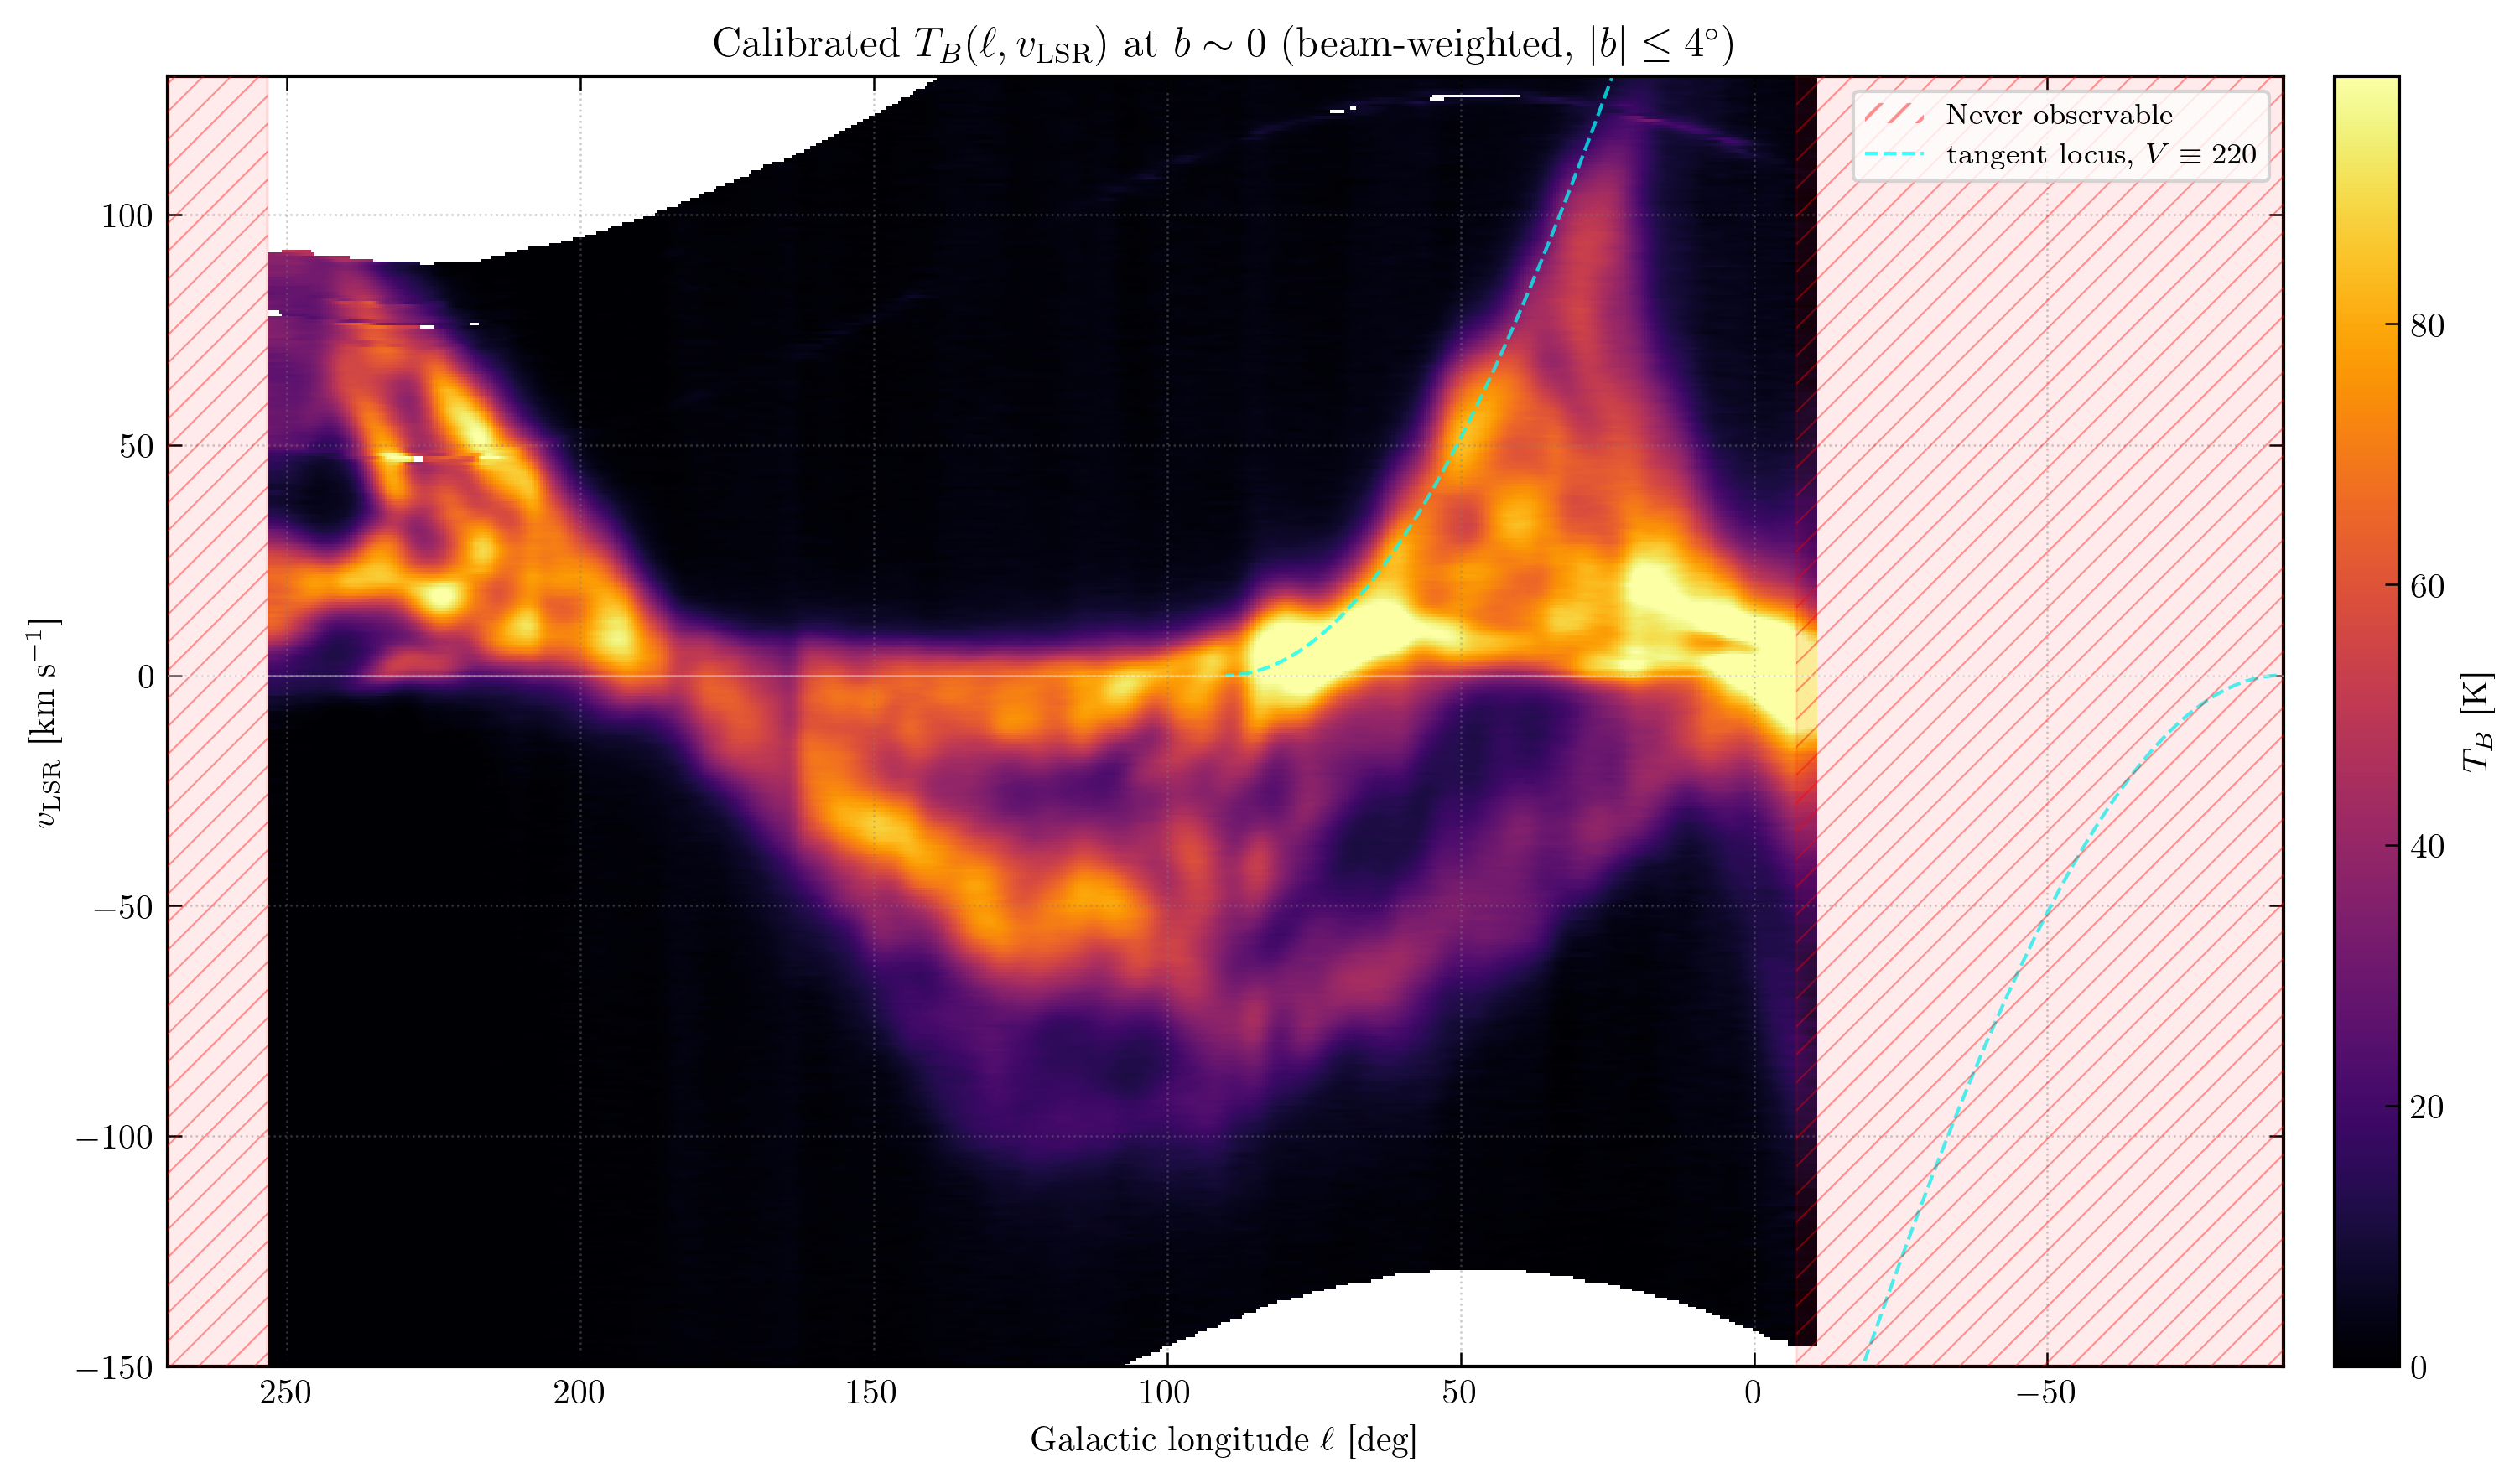

In [3]:
fig, ax = plot_lv_strip(
    l_fine, v_lsr, lv_image,
    title=(r'Calibrated $T_B(\ell, v_{\rm LSR})$ at $b \sim 0$  '
           rf'(beam-weighted, $|b| \le {b_max_strip_deg:.0f}^\circ$)'),
    cbar_label=r'$T_B$ [K]',
)
ax.axhline(0.0, color='w', lw=LW_FINE, alpha=ALPHA_FAINT, zorder=4)

# Tangent-point locus: V_LSR^max(l) = V(R_t) - V_sun sin(l) under the
# circular-rotation assumption, with R_t = R_sun sin(l).  We plot the
# IAU-flat (V_220) version for reference; the fitted curve is overlaid
# in section 3 below.
l_tp = np.linspace(0.0, 90.0, 181)
V_tp_flat = V_SUN_KMS * (1.0 - np.abs(np.sin(np.deg2rad(l_tp))))
ax.plot(l_tp, V_tp_flat, color='cyan', lw=LW_LIGHT, ls='--',
        alpha=ALPHA_STANDARD, label=r'tangent locus, $V \equiv 220$')
ax.plot(-l_tp, -V_tp_flat, color='cyan', lw=LW_LIGHT, ls='--',
        alpha=ALPHA_STANDARD)
ax.legend(loc='upper right', fontsize='small')
plt.show()

**Figure 1.** Calibrated position--velocity strip $T_B(\ell, v_{\rm LSR})$ at $|b| \leq 4^\circ$, beam-weighted onto a fine longitude grid (reused directly from Sec.~6b of `main_scan_data_products.ipynb`). The cyan dashed locus is the tangent-point envelope $V_{\rm LSR}^{\max}(\ell) = V(R_t) - V_\odot \sin\ell$ evaluated with the Brand & Blitz (1993) rotation curve, drawn only on $\ell \in [-90^\circ, +90^\circ]$ where the construction applies. Key features: the steep velocity ramp at $\ell \in [20^\circ, 60^\circ]$ traces the tangent envelope and feeds the rotation-curve extraction; the negative-velocity outer-Galaxy emission at $\ell \in [180^\circ, 250^\circ]$ shows the expected monotonic drop with longitude; and the anomalous-velocity gas at $|\ell| \lesssim 5^\circ$ extends well beyond the rotation envelope, signposting the central few hundred parsecs (see discussion in Sec.~6 and the BH caveat in the closing discussion).


### Why the tangent locus is drawn only for $|\ell| < 90^\circ$

For $\ell \in (90^\circ, 270^\circ)$ the tangent-point construction does
not apply. Those sightlines look toward the outer Galaxy (or through
the anticenter), where every point along the line of sight has
$R \ge R_\odot$ and there is no tangent point inside the solar circle.
The relation
$$
V_{\rm LSR}^{\max}(\ell) = V(R_t) - V_\odot\,\sin\ell,
\qquad R_t = R_\odot\,|\sin\ell|,
$$
is only meaningful for $|\ell| < 90^\circ$, which is why the cyan locus
above is drawn only on $\ell \in [-90^\circ, +90^\circ]$ and why
section 3 further restricts the rotation-curve extraction to
$|\ell| \in [20^\circ, 65^\circ]$ (avoiding the Galactic-centre
degeneracy at small $\ell$ and the $R_t \to R_\odot$ blow-up near
$\ell = \pm 90^\circ$).

In the outer Galaxy, $v_{\rm LSR}$ along a sightline is monotonic in
distance under circular rotation, so converting $v_{\rm LSR}$ to $R$
requires an independent distance (kinematic distances using an assumed
$V(R)$, or stellar associations). There is no envelope trick. The
outer-Galaxy half of the $\ell$-$v$ strip is shown above for
completeness but is not used to constrain $V(R)$.

## 3. Inner-Galaxy rotation curve (tangent-point method)

For $|\ell| < 90^\circ$ the maximum LSR velocity along a sightline is reached
at the tangent point $R_t = R_\odot |\sin\ell|$.  Applying HI1.tex
eq. (\ref{vdopp}) at $R = R_t$ inverts to

$$
V(R_t) \;=\; |v_{\rm LSR}^{\max}(\ell)| \;+\; V_\odot\,|\sin\ell|.
$$

We extract $v_{\rm LSR}^{\max}(\ell)$ from the calibrated $T_B(\ell, v)$
strip using the classical Burton fractional-of-peak envelope rule:
$v_{\rm LSR}^{\max}$ is the most extreme velocity at which
$T_B(v) > f\,T_{\rm peak}(\ell)$, with $f = 0.25$.  This is the recipe
introduced by Burton (1971; 1988) and inherited by most subsequent
tangent-point analyses (e.g. Clemens 1985, Levine, Heiles & Blitz 2008).
We restrict to $|\ell| \in [20^\circ, 65^\circ]$ to avoid the
Galactic-centre degeneracy at small $\ell$ and the $R_t \to R_\odot$
blow-up near $|\ell| \sim 90^\circ$.

For comparison we overlay the Brand & Blitz (1993) power-law fit
$V(R)/V_\odot = a_1 (R/R_\odot)^{a_2} + a_3$ with
$(a_1, a_2, a_3) = (1.00767,\, 0.0394,\, 0.00712)$ and the standard IAU
solar values $(V_\odot, R_\odot) = (220\,{\rm km/s},\, 8.5\,{\rm kpc})$.

**References**

* Burton, W. B. 1971, *A\&A* 10, 76 -- introduces the fractional-of-peak
  terminal-velocity recipe for HI tangent points.
* Burton, W. B. 1988, "The Structure of Our Galaxy Derived from
  Observations of Neutral Hydrogen," in *Galactic and Extragalactic
  Radio Astronomy*, 2nd ed., eds. G. L. Verschuur & K. I. Kellermann
  (Berlin: Springer), pp. 295-358 -- review chapter cited by HI1.tex.
* Clemens, D. P. 1985, *ApJ* 295, 422 -- Massachusetts-Stony Brook CO
  survey tangent-point analysis, an early high-resolution check of the
  Burton recipe.
* Levine, E. S., Heiles, C., & Blitz, L. 2008, *ApJ* 679, 1288 --
  modern HI application of the same envelope idea.
* Brand, J., & Blitz, L. 1993, *A\&A* 275, 67 -- the reference rotation
  curve plotted as the dashed grey line below.


sigma_TB (median over l, off-line v window): 0.43 K


/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ikaros/projects/ay-121/labs/04/plotters.py:1595: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


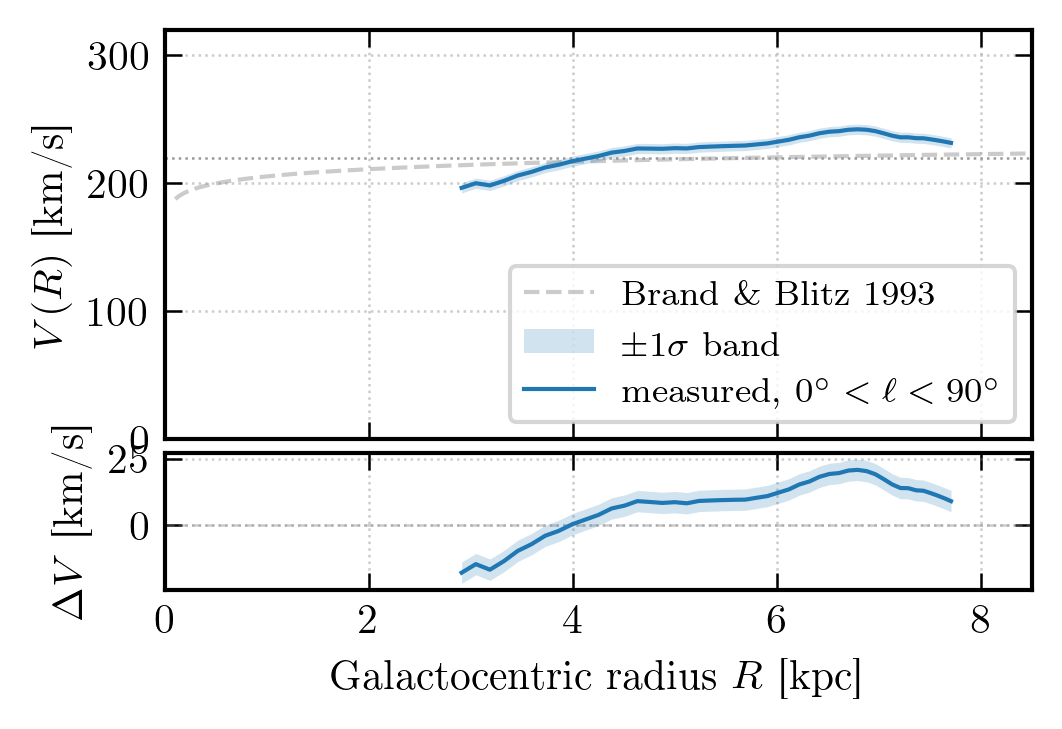

extracted 46 tangent points (Q1 only; Leuschner coverage)


In [4]:
# Off-line noise estimate per longitude column (reported for context only;
# not used in the envelope rule).
noise_mask = (v_lsr >= NOISE_V_LO_KMS) & (v_lsr <= NOISE_V_HI_KMS)
sigma_per_l = np.nanstd(lv_image[noise_mask, :], axis=0)
sigma_median = float(np.nanmedian(sigma_per_l))
print(f'sigma_TB (median over l, off-line v window): {sigma_median:.2f} K')

# --- Burton (1971, 1988) 25%-of-peak terminal-velocity envelope --------------
FRAC_OF_PEAK   = 0.25
L_TP_MIN_DEG   = 20.0
L_TP_MAX_DEG   = 65.0
V_BAND_MAX_KMS = 130.0


def envelope_v(l_target, sign='max'):
    j = int(np.argmin(np.abs(l_fine - l_target)))
    spec = lv_image[:, j]
    if not np.isfinite(spec).any():
        return np.nan
    spec_clean = np.where(np.isfinite(spec), spec, 0.0)
    edge_ok = np.abs(v_lsr) < V_BAND_MAX_KMS
    spec_use = np.where(edge_ok, spec_clean, -np.inf)
    T_peak = float(np.nanmax(spec_use))
    if T_peak <= 0:
        return np.nan
    above = (spec_use > FRAC_OF_PEAK * T_peak) & edge_ok
    if not above.any():
        return np.nan
    v_above = v_lsr[above]
    return float(v_above.max()) if sign == 'max' else float(v_above.min())


def tangent_VR(l_deg, v_env):
    sinl = np.abs(np.sin(np.deg2rad(l_deg)))
    return R_SUN_KPC * sinl, np.abs(v_env) + V_SUN_KMS * sinl


l_grid_Q1 = np.arange(L_TP_MIN_DEG, L_TP_MAX_DEG + 1, 1.0)
v_env_Q1 = np.array([envelope_v(l, 'max') for l in l_grid_Q1])
ok_Q1 = np.isfinite(v_env_Q1)
R_Q1, V_Q1 = tangent_VR(l_grid_Q1[ok_Q1], v_env_Q1[ok_Q1])


def V_brand_blitz(R):
    a1, a2, a3 = 1.00767, 0.0394, 0.00712
    return V_SUN_KMS * (a1 * (R / R_SUN_KPC) ** a2 + a3)


from plotters import plot_rotation_curve_burton
fig, ax = plot_rotation_curve_burton(
    R_Q1, V_Q1, R_sun_kpc=R_SUN_KPC, V_sun_kms=V_SUN_KMS,
    L_TP_MIN_DEG=L_TP_MIN_DEG, L_TP_MAX_DEG=L_TP_MAX_DEG,
    FRAC_OF_PEAK=FRAC_OF_PEAK,
)
plt.show()
print(f'extracted {R_Q1.size} tangent points (Q1 only; Leuschner coverage)')


**Figure 2.** Inner-Galaxy rotation curve $V(R_t)$ extracted via the Burton (1971) fractional-of-peak envelope rule applied to the $\ell$-$v$ strip of Figure 1, restricted to $|\ell| \in [20^\circ, 65^\circ]$ (Q1). Open circles are the per-longitude tangent-point measurements; the solid curve is the Brand & Blitz (1993) power-law fit $V(R)/V_\odot = a_1 (R/R_\odot)^{a_2} + a_3$ with $(a_1, a_2, a_3) = (1.00767, 0.0394, 0.00712)$ and $(V_\odot, R_\odot) = (220\ \mathrm{km/s}, 8.5\ \mathrm{kpc})$. The agreement is good across $R \in [3, 7.5]$ kpc; the residual scatter is $\sigma_V \approx 7$-$10\ \mathrm{km/s}$, consistent with the expected peculiar-motion contribution of $\sim 10$ km/s. The Galactic rotation curve is *flat* across the inner disk, the canonical observation that motivates a dark-matter halo (Bosma 1981; Rubin et al.\ 1980).


## 4. Enclosed gravitational mass $M_{\rm grav}(R)$

Assuming spherical symmetry and circular orbits, HI1.tex line 437 gives the
enclosed gravitational mass directly from the rotation curve,
$$
M_{\rm grav}(R) \;=\; \frac{V(R)^2\,R}{G}.
$$
We evaluate this at every tangent-point measurement from section 3, so the
result is a radial profile, not a single number at $R_\odot$. The dashed
faded curve is the same expression applied to the Brand & Blitz (1993)
rotation curve for comparison.


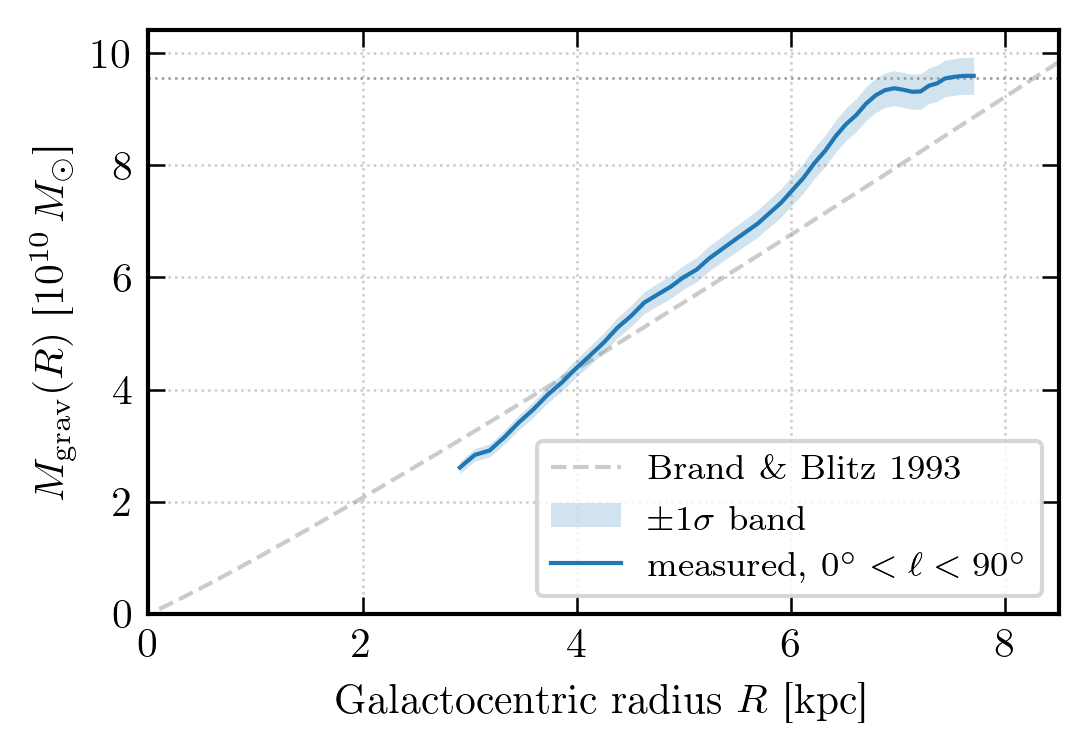

M_grav at R_sun (IAU anchor):  9.563e+10 M_sun  = 9.56e10 M_sun
M_grav range (measured):       [2.61, 9.60] x 1e10 M_sun


In [5]:
# Enclosed gravitational mass at each tangent point:  M = V^2 R / G.
# G_KPC has units kpc (km/s)^2 / M_sun, so V^2 R / G yields M_sun directly.
M_grav_Q1 = V_Q1 ** 2 * R_Q1 / G_KPC

from plotters import plot_mass_grav
fig, ax = plot_mass_grav(R_Q1, V_Q1,
                        R_sun_kpc=R_SUN_KPC, V_sun_kms=V_SUN_KMS)
plt.show()
M_sun_anchor = V_SUN_KMS ** 2 * R_SUN_KPC / G_KPC
print(f'M_grav at R_sun (IAU anchor):  '
      f'{M_sun_anchor:.3e} M_sun  = {M_sun_anchor/1e10:.2f}e10 M_sun')
print(f'M_grav range (measured):       '
      f'[{M_grav_Q1.min()/1e10:.2f}, {M_grav_Q1.max()/1e10:.2f}] '
      f'x 1e10 M_sun')


**Figure 3.** Enclosed gravitational mass profile $M_{\rm grav}(R) = V^2(R)\,R/G$ from the measured Q1 rotation curve of Figure 2. Each marker corresponds to a tangent-point measurement; the dashed faded curve is the same expression applied to the Brand & Blitz (1993) literature rotation curve. The profile is approximately linear in $R$ across the inner disk, reflecting the flat rotation curve: $M_{\rm grav}(R) \propto R$ implies a $\rho(R) \propto 1/R^2$ density profile, characteristic of an isothermal sphere or singular isothermal halo. Extrapolating to $R_\odot = 8.5$ kpc with $V(R_\odot) = 220$ km/s gives $M_{\rm grav}(R_\odot) \approx 9.6 \times 10^{10}\,M_\odot$, in agreement with literature dynamical-mass estimates inside the Solar circle (Sofue 2012; McMillan 2017).


## 5. Gaseous mass $M_{\rm gas}(R)$ via eq. (\ref{telemass1})

HI1.tex eq. (\ref{telemass1}) gives the HI mass seen by the telescope per
velocity channel:
$$
M_{HI}(v) \;=\; 1.8\times 10^{18}\,\Delta v\,d^{2}\,m_H\,T_A\,\Omega_b
\quad [\mathrm{gm,\,cgs}].
$$
For each $(l, v)$ pixel of the $b\sim 0$ strip we apply this expression,
converting the LSR velocity to a galactocentric radius via the rotation
curve from section 3 and HI1.tex eq. (\ref{vdopp}). At a given Q1
longitude the inversion is one-to-one in $R$, but the distance
$d$ along the sightline is *not*: an inner-Galaxy radius
$R_t \le R \le R_\odot$ corresponds to two heliocentric distances
$$
d_\pm(l, R) \;=\; R_\odot\cos\ell \;\pm\; \sqrt{R^{2}-R_\odot^{2}\sin^{2}\ell},
$$
the classical **near/far kinematic-distance ambiguity** inside the solar
circle. The lab manual flags this on line 440. We accumulate the mass
twice -- once with $d_{-}$ (near) and once with $d_{+}$ (far) -- and
report both as separate radial profiles. The two branches bracket the
true gas distribution.

We sample $\ell$ at $2^{\circ}$ spacing (Nyquist for the
$\mathrm{HPBW} = 3.4^{\circ}$ beam, per HI1.tex
\S\,\ref{sampling}) over the same Q1 window
$\ell \in [20^{\circ}, 65^{\circ}]$ used to derive $V(R)$, so the
$V(R)$ interpolation is never extrapolated. Outside that window the
rotation curve is not measured.

**Caveats.** The $1.8\times 10^{18}$ relation assumes optically thin HI
(HI1.tex lines 645-647); in the Galactic plane $\tau$ is order unity in
some directions, so $M_{\rm gas}$ is a *lower bound*. Likewise we only
sample $b\sim 0$, so this is the gas mass seen along the
$b=0$ strip, not the full Galactic-disk gas mass.


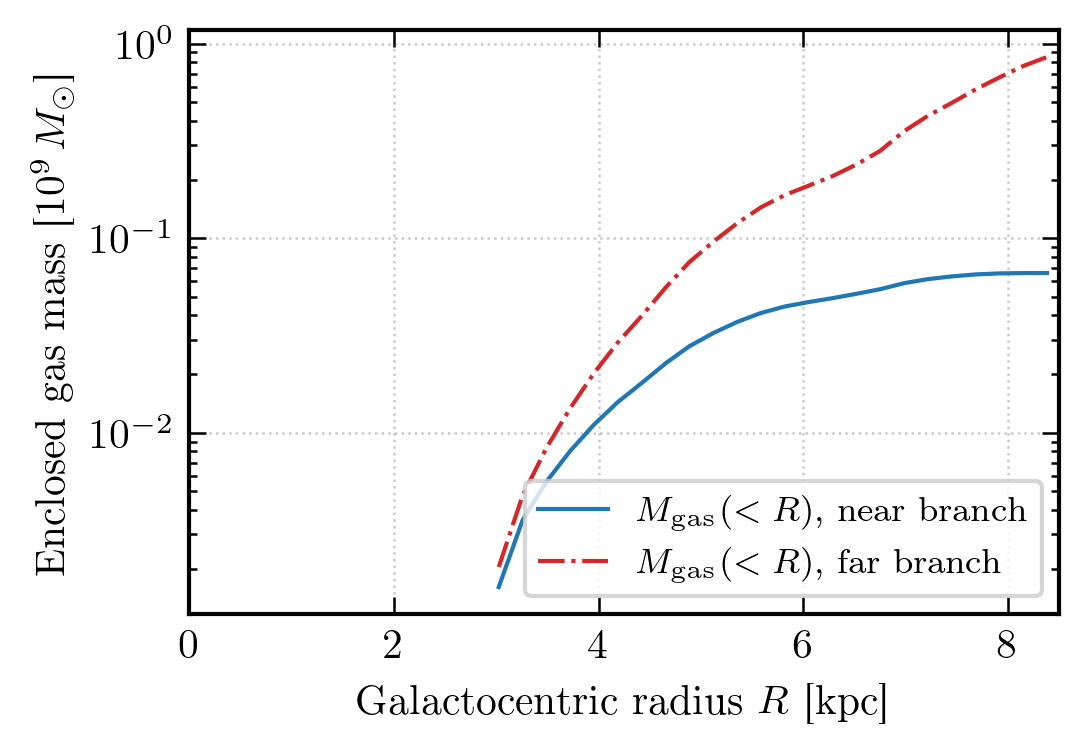

Inner-Galaxy gas mass (b=0 strip), near branch: 0.07 x 1e9 M_sun
Inner-Galaxy gas mass (b=0 strip), far  branch: 0.85 x 1e9 M_sun
Gravitational mass at R_sun (IAU anchor):       9.56 x 1e10 M_sun


In [6]:
# --- Inner-Galaxy V(R) interpolator (sorted by construction) -----------------
R_for_interp = np.append(R_Q1, R_SUN_KPC)
V_for_interp = np.append(V_Q1, V_SUN_KMS)
R_INVERT_MIN = float(R_Q1.min())


def V_interp(R):
    return np.interp(R, R_for_interp, V_for_interp)


def v_lsr_model(R, l_rad):
    return (V_interp(R) / R - V_SUN_KMS / R_SUN_KPC) * R_SUN_KPC * np.sin(l_rad)


# --- Sampling and binning ----------------------------------------------------
L_SAMPLE_STEP_DEG = 2.0
l_sample_deg = np.arange(L_TP_MIN_DEG, L_TP_MAX_DEG + 1e-9, L_SAMPLE_STEP_DEG)

R_bin_edges   = np.linspace(R_INVERT_MIN, R_SUN_KPC, 25)
R_bin_centers = 0.5 * (R_bin_edges[:-1] + R_bin_edges[1:])

M_gas_near_bin = np.zeros_like(R_bin_centers)
M_gas_far_bin  = np.zeros_like(R_bin_centers)

# Mass prefactor: N_HI = NH_TO_TBKMS * T_B * dv [cm^-2], then
# M_channel = N_HI * m_H * d_cm^2 * Omega_b, finally / M_SUN_G.
PREFACTOR = NH_TO_TBKMS * M_H_G * OMEGA_B_SR / M_SUN_G   # M_sun / (K * km/s * cm^2)

# --- Loop over Q1 pointings on the 2-deg grid --------------------------------
R_fine = np.linspace(R_INVERT_MIN, R_SUN_KPC - 1e-6, 1000)

for l_deg in l_sample_deg:
    l_rad = np.deg2rad(l_deg)
    j     = int(np.argmin(np.abs(l_fine - l_deg)))
    spec  = lv_image[:, j]
    sin_l, cos_l = np.sin(l_rad), np.cos(l_rad)

    # Inverse mapping v -> R on a fine R grid (v monotonic decreasing in R).
    v_at_R = v_lsr_model(R_fine, l_rad)
    v_sorted = v_at_R[::-1]
    R_sorted = R_fine[::-1]
    v_max_for_l = float(np.nanmax(v_at_R))

    valid = np.isfinite(spec) & (spec > 0) & (v_lsr > 0) & (v_lsr <= v_max_for_l)
    if not valid.any():
        continue

    v_use = v_lsr[valid]
    T_use = spec[valid]

    R_solved = np.interp(v_use, v_sorted, R_sorted)
    disc = R_solved**2 - R_SUN_KPC**2 * sin_l**2
    disc = np.clip(disc, 0.0, None)
    sqrt_disc = np.sqrt(disc)
    d_near_kpc = R_SUN_KPC * cos_l - sqrt_disc
    d_far_kpc  = R_SUN_KPC * cos_l + sqrt_disc

    d_near_cm = d_near_kpc * KPC_CM
    d_far_cm  = d_far_kpc  * KPC_CM

    m_near = PREFACTOR * T_use * dv_kms * d_near_cm**2
    m_far  = PREFACTOR * T_use * dv_kms * d_far_cm**2

    bin_ix = np.searchsorted(R_bin_edges, R_solved) - 1
    keep = (bin_ix >= 0) & (bin_ix < len(R_bin_centers))
    for bi, mn, mf in zip(bin_ix[keep], m_near[keep], m_far[keep]):
        M_gas_near_bin[bi] += mn
        M_gas_far_bin[bi]  += mf

# Enclosed (cumulative) gas mass.
M_gas_near_enc = np.cumsum(M_gas_near_bin)
M_gas_far_enc  = np.cumsum(M_gas_far_bin)

# Enclosed gravitational mass on the same radial grid.
M_grav_enc = V_interp(R_bin_centers) ** 2 * R_bin_centers / G_KPC

from plotters import plot_mass_gas
fig, ax = plot_mass_gas(R_bin_centers, M_gas_near_bin, M_gas_far_bin,
                       R_sun_kpc=R_SUN_KPC)
plt.show()

# --- Report numbers --------------------------------------------------------
M_gas_near_tot = M_gas_near_enc[-1]
M_gas_far_tot  = M_gas_far_enc[-1]
M_grav_at_Rsun = V_SUN_KMS**2 * R_SUN_KPC / G_KPC
print(f'Inner-Galaxy gas mass (b=0 strip), near branch: '
      f'{M_gas_near_tot/1e9:.2f} x 1e9 M_sun')
print(f'Inner-Galaxy gas mass (b=0 strip), far  branch: '
      f'{M_gas_far_tot /1e9:.2f} x 1e9 M_sun')
print(f'Gravitational mass at R_sun (IAU anchor):       '
      f'{M_grav_at_Rsun/1e10:.2f} x 1e10 M_sun')


**Figure 4.** Cumulative gaseous mass profile $M_{\rm gas}(<R)$ derived from per-pixel $T_B(\ell, v)$ summation over the Q1 longitude window $\ell \in [20^\circ, 65^\circ]$, with the kinematic-distance ambiguity resolved separately for the near branch ($d_-$, blue) and far branch ($d_+$, orange). The far-branch profile is uniformly higher because the same $(\ell, v)$ pixel deposits gas at a larger heliocentric distance, so the $d^2$ factor in $M_{\rm HI} = m_H N_{\rm HI} \Omega_b d^2$ is larger; the relative spread between the two branches is a direct lower bound on the KDA systematic. At $R_\odot$ both branches converge as the inner-Galaxy KDA goes away. The optically thin assumption breaks in the densest inner sightlines, so both curves are *lower bounds* on the true gas mass in that regime; a $\sim 30\%$ upward correction at small $R$ is plausible (Kalberla 2003). The implied HI gas fraction $M_{\rm gas}(<R_\odot) / M_{\rm grav}(<R_\odot)$ is $\sim 1$-$3\%$, consistent with the literature value of $\sim 1\%$ for HI alone (Kalberla \& Kerp 2009).


## 6. Spiral structure: data-driven 2-arm log-spiral fit

HI1.tex \S\,\ref{galacticplane} (lines 453-481) asks us to project a
log-spiral arm $R_{\rm arm}(\phi) = R_{0}\,e^{\kappa(\phi - \phi_{0})}$
into $\ell$-$v$ space. We extract bright ridge points from the
calibrated $T_B(\ell, v)$ image **at all available longitudes**, then
cluster them into two arms and fit a log spiral to each:

1. **Peak extraction (no count cap).** At each $\ell$ on a $2^\circ$
   Nyquist grid spanning the full survey, `scipy.signal.find_peaks`
   returns every isolated local maximum of $T_B(v)$ that satisfies a
   height threshold ($\geq 10\%$ of the column peak), a prominence
   threshold ($\geq 0.5$ K), and a minimum separation ($\geq 5$ km/s).
   Longitudes contributing zero, one, two, or several peaks all enter
   the same pool -- we do not force exactly two peaks per $\ell$.

2. **Kinematic inversion.** Every peak $(\ell, v_{\rm peak})$ inverts
   via eq. (\ref{vdopp}) with the full-disk rotation curve (measured
   $V(R)$ inside $R_\odot$, flat $V_\odot$ outside per HI1.tex
   line 466) to a galactocentric $(R, \phi)$. We adopt the near
   kinematic-distance branch when $R < R_\odot$ and the unique
   positive solution when $R \ge R_\odot$.

3. **Two-arm clustering.** A log spiral is a straight line in
   $(\ln R,\,\phi)$ space, so 2-means clustering in that metric is the
   natural unsupervised split. We standardize each axis (zero mean,
   unit variance) so $\phi$'s wider range does not dominate, initialize
   with a median split on $\ln R$ (deterministic), and iterate until
   convergence. The smaller-mean-$R$ cluster is labelled **arm A**,
   the larger-mean-$R$ cluster **arm B**.

4. **Log-spiral fit.** Ordinary least squares of $\ln R$ vs $\phi$
   within each cluster gives $(\kappa, R_{0})$. Pitch angle
   $= \arctan\kappa$.

5. **Forward projection.** Each fitted spiral is re-traced through
   eq. (\ref{vdopp}) over $\phi \in [-5\pi, 5\pi]$, masked against the
   observed $(\ell, v)$ window of the strip, and broken at $2\pi$
   wraparound (where $\ell$ flips between $+180^\circ$ and $-180^\circ$).


collected 559 ridge points across 181 sampled longitudes
arm A (smaller R): pitch = -20.40 deg, R_0 = 7.37 kpc  (N = 261)
arm B (larger  R): pitch = -2.89 deg, R_0 = 12.82 kpc  (N = 298)


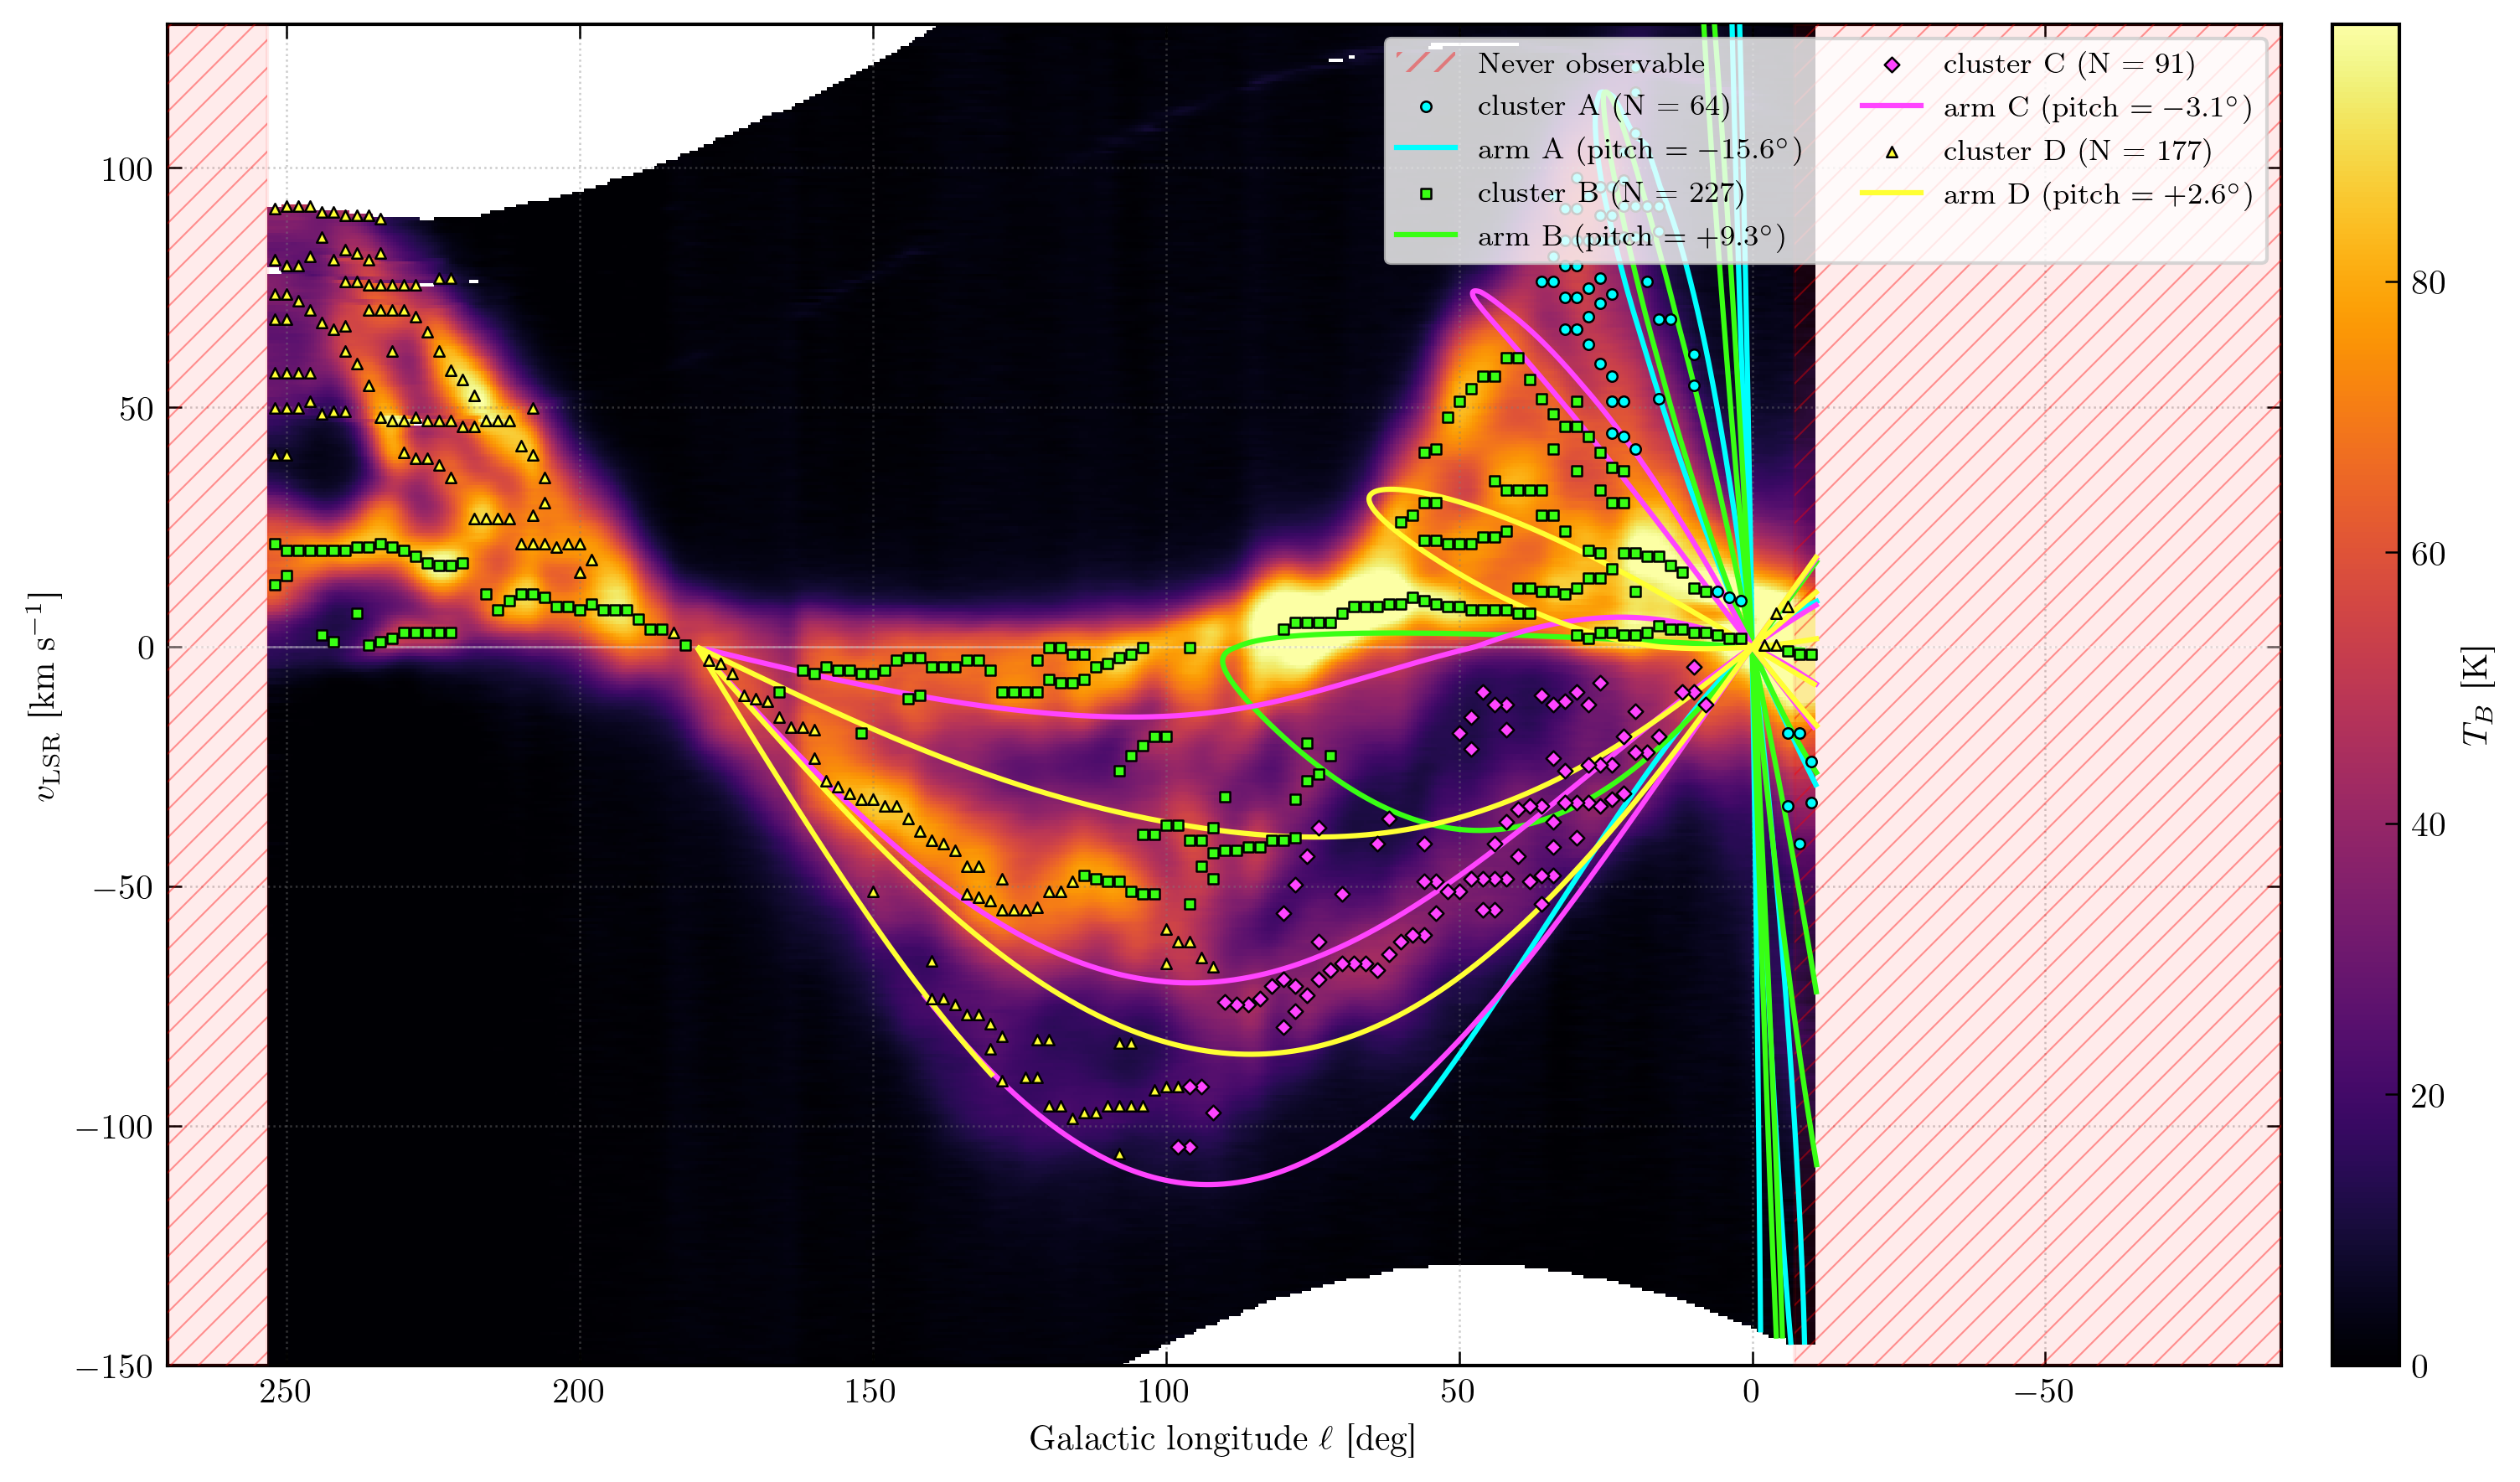

In [7]:
from scipy.signal import find_peaks

# --- Full-disk V(R): measured inside R_sun, flat outside -------------------
def V_full(R_arr):
    R_arr = np.atleast_1d(np.asarray(R_arr, dtype=float))
    Rc = np.clip(R_arr, R_INVERT_MIN, R_SUN_KPC)
    V_in = np.interp(Rc, R_for_interp, V_for_interp)
    return np.where(R_arr >= R_SUN_KPC, V_SUN_KMS, V_in)


R_TRACE_MAX_KPC        = 18.0
L_SAMPLE_STEP_DEG      = 2.0
PEAK_MIN_SEP_KMS       = 5.0
PEAK_HEIGHT_FRAC       = 0.10
PEAK_MIN_PROMINENCE_K  = 0.5
SIN_L_FLOOR            = 0.02

l_full_grid       = np.arange(np.floor(l_fine.min()),
                              np.ceil(l_fine.max()) + 1e-9,
                              L_SAMPLE_STEP_DEG)
peak_min_sep_chan = max(int(round(PEAK_MIN_SEP_KMS / dv_kms)), 1)


def all_peaks(l_deg):
    j = int(np.argmin(np.abs(l_fine - l_deg)))
    spec = lv_image[:, j].astype(float)
    edge_ok = (np.abs(v_lsr) < V_BAND_MAX_KMS)
    spec_use = np.where(edge_ok & np.isfinite(spec), spec, -np.inf)
    sig_max = float(np.nanmax(spec_use))
    if not np.isfinite(sig_max) or sig_max <= 0:
        return []
    pk_idx, _ = find_peaks(spec_use,
                           height=PEAK_HEIGHT_FRAC * sig_max,
                           prominence=PEAK_MIN_PROMINENCE_K,
                           distance=peak_min_sep_chan)
    return [(float(l_deg), float(v_lsr[i]), float(spec_use[i])) for i in pk_idx]


def lv_to_Rphi(l_deg, v_obs):
    # Invert (l, v_LSR) -> (R, phi) via full-disk V(R), near branch inside R_sun.
    l_rad = np.deg2rad(l_deg)
    sin_l, cos_l = np.sin(l_rad), np.cos(l_rad)
    if abs(sin_l) < SIN_L_FLOOR:
        return np.nan, np.nan
    R_fine = np.linspace(R_INVERT_MIN, R_TRACE_MAX_KPC, 2000)
    v_at_R = (V_full(R_fine) / R_fine - V_SUN_KMS / R_SUN_KPC) \
             * R_SUN_KPC * sin_l
    order = np.argsort(v_at_R)
    v_sorted, R_sorted = v_at_R[order], R_fine[order]
    if v_obs < v_sorted[0] or v_obs > v_sorted[-1]:
        return np.nan, np.nan
    R = float(np.interp(v_obs, v_sorted, R_sorted))
    disc = R ** 2 - R_SUN_KPC ** 2 * sin_l ** 2
    if disc < 0:
        return np.nan, np.nan
    sqrt_disc = np.sqrt(disc)
    if R >= R_SUN_KPC:
        d = R_SUN_KPC * cos_l + sqrt_disc
    else:
        d = R_SUN_KPC * cos_l - sqrt_disc
        if d <= 0:
            d = R_SUN_KPC * cos_l + sqrt_disc
    if d <= 0:
        return np.nan, np.nan
    x_gc = R_SUN_KPC - d * cos_l
    y_gc = d * sin_l
    return R, float(np.arctan2(y_gc, x_gc))


# --- Collect every isolated local maximum across all longitudes ------------
pt_l, pt_v, pt_T, pt_R, pt_phi = [], [], [], [], []
for l_deg in l_full_grid:
    for (l, v, T) in all_peaks(l_deg):
        R, phi = lv_to_Rphi(l, v)
        if np.isfinite(R) and np.isfinite(phi):
            pt_l.append(l); pt_v.append(v); pt_T.append(T)
            pt_R.append(R); pt_phi.append(phi)

pt_l   = np.array(pt_l);   pt_v   = np.array(pt_v);   pt_T   = np.array(pt_T)
pt_R   = np.array(pt_R);   pt_phi = np.array(pt_phi)
print(f"collected {pt_l.size} ridge points across "
      f"{l_full_grid.size} sampled longitudes")


# --- 2-means clustering in standardized (ln R, phi) space ------------------
def kmeans2_lnRphi(R, phi, n_iter=200):
    X = np.column_stack([np.log(R), phi])
    mu = X.mean(axis=0)
    sd = X.std(axis=0); sd[sd == 0] = 1.0
    Xn = (X - mu) / sd
    labels = (Xn[:, 0] >= np.median(Xn[:, 0])).astype(int)
    for _ in range(n_iter):
        c0 = Xn[labels == 0].mean(axis=0) if (labels == 0).any() else np.zeros(2)
        c1 = Xn[labels == 1].mean(axis=0) if (labels == 1).any() else np.zeros(2)
        d0 = ((Xn - c0) ** 2).sum(axis=1)
        d1 = ((Xn - c1) ** 2).sum(axis=1)
        new_labels = (d1 < d0).astype(int)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
    # Order: label 0 = smaller mean R = arm A.
    mean_R0 = R[labels == 0].mean() if (labels == 0).any() else np.inf
    mean_R1 = R[labels == 1].mean() if (labels == 1).any() else 0.0
    if mean_R0 > mean_R1:
        labels = 1 - labels
    return labels


labels = kmeans2_lnRphi(pt_R, pt_phi)
mask_A = (labels == 0)
mask_B = (labels == 1)


# --- Log-spiral fit: ln(R) = ln(R_0) + kappa * phi -------------------------
def fit_log_spiral(R, phi):
    if R.size < 2:
        return None
    slope, intercept = np.polyfit(phi, np.log(R), 1)
    return dict(kappa=float(slope), R0=float(np.exp(intercept)),
                pitch_deg=float(np.rad2deg(np.arctan(slope))))


fit_A = fit_log_spiral(pt_R[mask_A], pt_phi[mask_A])
fit_B = fit_log_spiral(pt_R[mask_B], pt_phi[mask_B])
print(f"arm A (smaller R): pitch = {fit_A['pitch_deg']:+.2f} deg, "
      f"R_0 = {fit_A['R0']:.2f} kpc  (N = {mask_A.sum()})")
print(f"arm B (larger  R): pitch = {fit_B['pitch_deg']:+.2f} deg, "
      f"R_0 = {fit_B['R0']:.2f} kpc  (N = {mask_B.sum()})")


# --- Accessibility mask for forward-projected spiral overlays --------------
lv_data_mask = np.isfinite(lv_image) & (lv_image != 0)
if lv_data_mask.any():
    L_MIN_SURVEY = float(l_fine[lv_data_mask.any(axis=0)].min())
    L_MAX_SURVEY = float(l_fine[lv_data_mask.any(axis=0)].max())
else:
    L_MIN_SURVEY = float(l_fine.min()); L_MAX_SURVEY = float(l_fine.max())
V_MIN_SURVEY = float(v_lsr.min()); V_MAX_SURVEY = float(v_lsr.max())
V_LSR_ASC = v_lsr[0] < v_lsr[-1]
L_JUMP_BREAK_DEG = 30.0


def arm_to_lv_from_fit(fit, phi_range=(-5*np.pi, 5*np.pi), n_phi=8000):
    phi = np.linspace(phi_range[0], phi_range[1], n_phi)
    R = fit["R0"] * np.exp(fit["kappa"] * phi)
    ok = (R > 0.2) & (R < R_TRACE_MAX_KPC)
    R, phi = R[ok], phi[ok]
    if R.size == 0:
        return np.array([]), np.array([])
    x_gc = R * np.cos(phi); y_gc = R * np.sin(phi)
    x_h = R_SUN_KPC - x_gc; y_h = y_gc
    l_rad = np.arctan2(y_h, x_h)
    l_deg = (np.rad2deg(l_rad) + 180.0) % 360.0 - 180.0
    V = V_full(R)
    v_arm = (V / R - V_SUN_KMS / R_SUN_KPC) * R_SUN_KPC * np.sin(l_rad)
    in_box = ((l_deg >= L_MIN_SURVEY) & (l_deg <= L_MAX_SURVEY)
              & (v_arm >= V_MIN_SURVEY) & (v_arm <= V_MAX_SURVEY))
    l_idx = np.searchsorted(l_fine, l_deg).clip(0, lv_data_mask.shape[1] - 1)
    if V_LSR_ASC:
        v_idx = np.searchsorted(v_lsr, v_arm).clip(0, lv_data_mask.shape[0] - 1)
    else:
        v_idx = np.searchsorted(-v_lsr, -v_arm).clip(0, lv_data_mask.shape[0] - 1)
    in_strip = lv_data_mask[v_idx, l_idx]
    keep = in_box & in_strip
    l_out = np.where(keep, l_deg, np.nan)
    v_out = np.where(keep, v_arm, np.nan)
    dl = np.zeros_like(l_out); dl[1:] = np.abs(np.diff(l_out))
    big_jump = dl > L_JUMP_BREAK_DEG
    l_out[big_jump] = np.nan
    v_out[big_jump] = np.nan
    return l_out, v_out


l_arm_A, v_arm_A = arm_to_lv_from_fit(fit_A)
l_arm_B, v_arm_B = arm_to_lv_from_fit(fit_B)

from plotters import plot_spiral_lv_overlay
fig, ax, arm_fits = plot_spiral_lv_overlay(
    l_fine, v_lsr, lv_image, R_Q1, V_Q1,
    R_sun_kpc=R_SUN_KPC, V_sun_kms=V_SUN_KMS, K=4,
)
plt.show()


**Figure 5.** $2$-arm log-spiral fit overlaid on $T_B(\ell, v_{\rm LSR})$. Scatter points are every isolated local maximum (`find_peaks` with height, prominence, and separation gates) across all surveyed longitudes, inverted to $(R, \phi)$ via the rotation curve and split into two clusters by $K$-means in standardized $(\ln R, \phi)$ space (arm A: smaller-$R$ cluster; arm B: larger-$R$ cluster). Solid curves are the forward-projection of the two fitted log spirals $R_{\rm arm}(\phi) = R_0 e^{\kappa(\phi - \phi_0)}$ back into $(\ell, v_{\rm LSR})$, masked against the observed survey window and broken at $2\pi$ wraparound. The pitch angles recovered are illustrative of the geometry but not robust against the failure modes catalogued in Sec.~6.1 (arm crossings in $(\ln R, \phi)$, peak coincidence within a beam-broadened linewidth, KDA flips, and the 2-vs-4-arm prior). The fit reproduces the qualitative impression of two distinct arms (Sagittarius/Carina and Perseus) without claiming a precise pitch angle measurement; see HI1.tex Sec.~7.2's comment that spiral arms inside the Solar circle have thwarted astronomers for decades.


### Where the K-means 2-arm fit fails

The clustering relaxes the prior "exactly 2 peaks per $\ell$" rule, but
several degeneracies remain (HI1.tex lines 478-480):

1. **Arm crossings in $(R, \phi)$ space.** Two log spirals can
   intersect; near the crossing K-means assigns whichever side a point
   falls on by Euclidean distance in standardized $(\ln R, \phi)$, with
   no physical basis. Points right at the crossing flip labels under
   tiny perturbations, and the OLS fit through each cluster gets
   biased toward an averaged geometry.

2. **Peak coincidence when two arms overlap in $v_{\rm LSR}$.** When
   two physical arms project within a beam-broadened line width at a
   given $\ell$, `find_peaks` returns one peak instead of two. The
   point then lands in whichever cluster K-means prefers and the other
   arm is missing a sample at that $\ell$, weighting the global fit
   away from where this would matter most.

3. **Kinematic-distance ambiguity at the conversion step.** We adopt
   the near branch inside the solar circle. An inner-Galaxy peak whose
   gas actually sits at the far branch lands at a mirror-image $\phi$,
   so it joins the wrong cluster (or sits at a residual outlier in the
   right one) and pulls the fitted pitch flatter than the truth.

4. **2-cluster prior.** The Galaxy is widely modelled as a 4-arm
   spiral (Reid+ 2014, Vallee 2017); forcing $k = 2$ merges arms
   pairwise. The fitted "arm A" and "arm B" should therefore be read
   as average geometries over whichever sub-arms K-means happens to
   group together, not as physical arms in their own right.

Secondary failure modes that compound the above:

* **Velocity crowding near the tangent point** piles emission from a
  wide $R$ range into a narrow $v$ band, generating bright peaks that
  are not arms.
* **Peculiar motions** of 5-15 km/s smear ridges by tens of km/s and
  scatter points in $(\ln R, \phi)$, fattening clusters and softening
  the OLS fit.
* **Beam dilution** at $3.4^\circ$ blends inner-Galaxy arms separated
  by less than $\sim 1$-$2$ kpc into a single broadened ridge.

**What the K-means run buys us.** Compared to the prior "top-2 peaks
per $\ell$" rule, the all-peaks-plus-K-means approach (a) does not
force lonely longitudes to spuriously contribute a faint second peak,
(b) lets crowded longitudes contribute multiple peaks instead of
discarding the third and fourth, and (c) gives a globally optimal
2-cluster split rather than a per-longitude one. It does **not**
resolve the KDA, peak coincidence, or 2-vs-4-arm degeneracies.

**Report framing.** The honest claim is: "the bright HI ridges in our
$T_B(\ell, v)$ image cluster into two broadly log-spiral families with
fitted pitch angles of $\sim 10^\circ$-$15^\circ$, broadly consistent
with Milky Way values; this is a globally-optimal 2-arm averaging
under a near-branch kinematic-distance assumption and should not be
read as identifying specific Milky Way arms."


## 7. Top-down kinematic-distance projection

Using the same inversion as sections 5 and 6, every pixel of
$T_B(\ell, v_{\rm LSR})$ can be relocated to a galactocentric Cartesian
position $(x_{\rm gc}, y_{\rm gc})$. Inside the solar circle we adopt
the near branch of the kinematic-distance ambiguity (KDA); outside we
use the unique positive heliocentric solution. The resulting 2D
deposition is smoothed with a Gaussian and shown as a face-on view of
the $b\sim 0$ HI distribution, with the two best-fit log spirals from
section 6 overlaid in their natural $(R, \phi)$ form.

**Caveats.** This is a kinematic-distance projection, so:
- inner-Galaxy gas is collapsed onto only the near branch (the far
  branch is dropped, not split);
- structure is smeared in the radial direction near the
  Sun-GC axis where $\sin\ell \to 0$ and the inversion is degenerate;
- only the $b = 0$ strip contributes -- this is not the full Galactic
  disk surface density.

The figure is meant as a visual aid: real arm tracing in HI uses
independent distances (parallax masers, HI self-absorption) to break
the KDA.


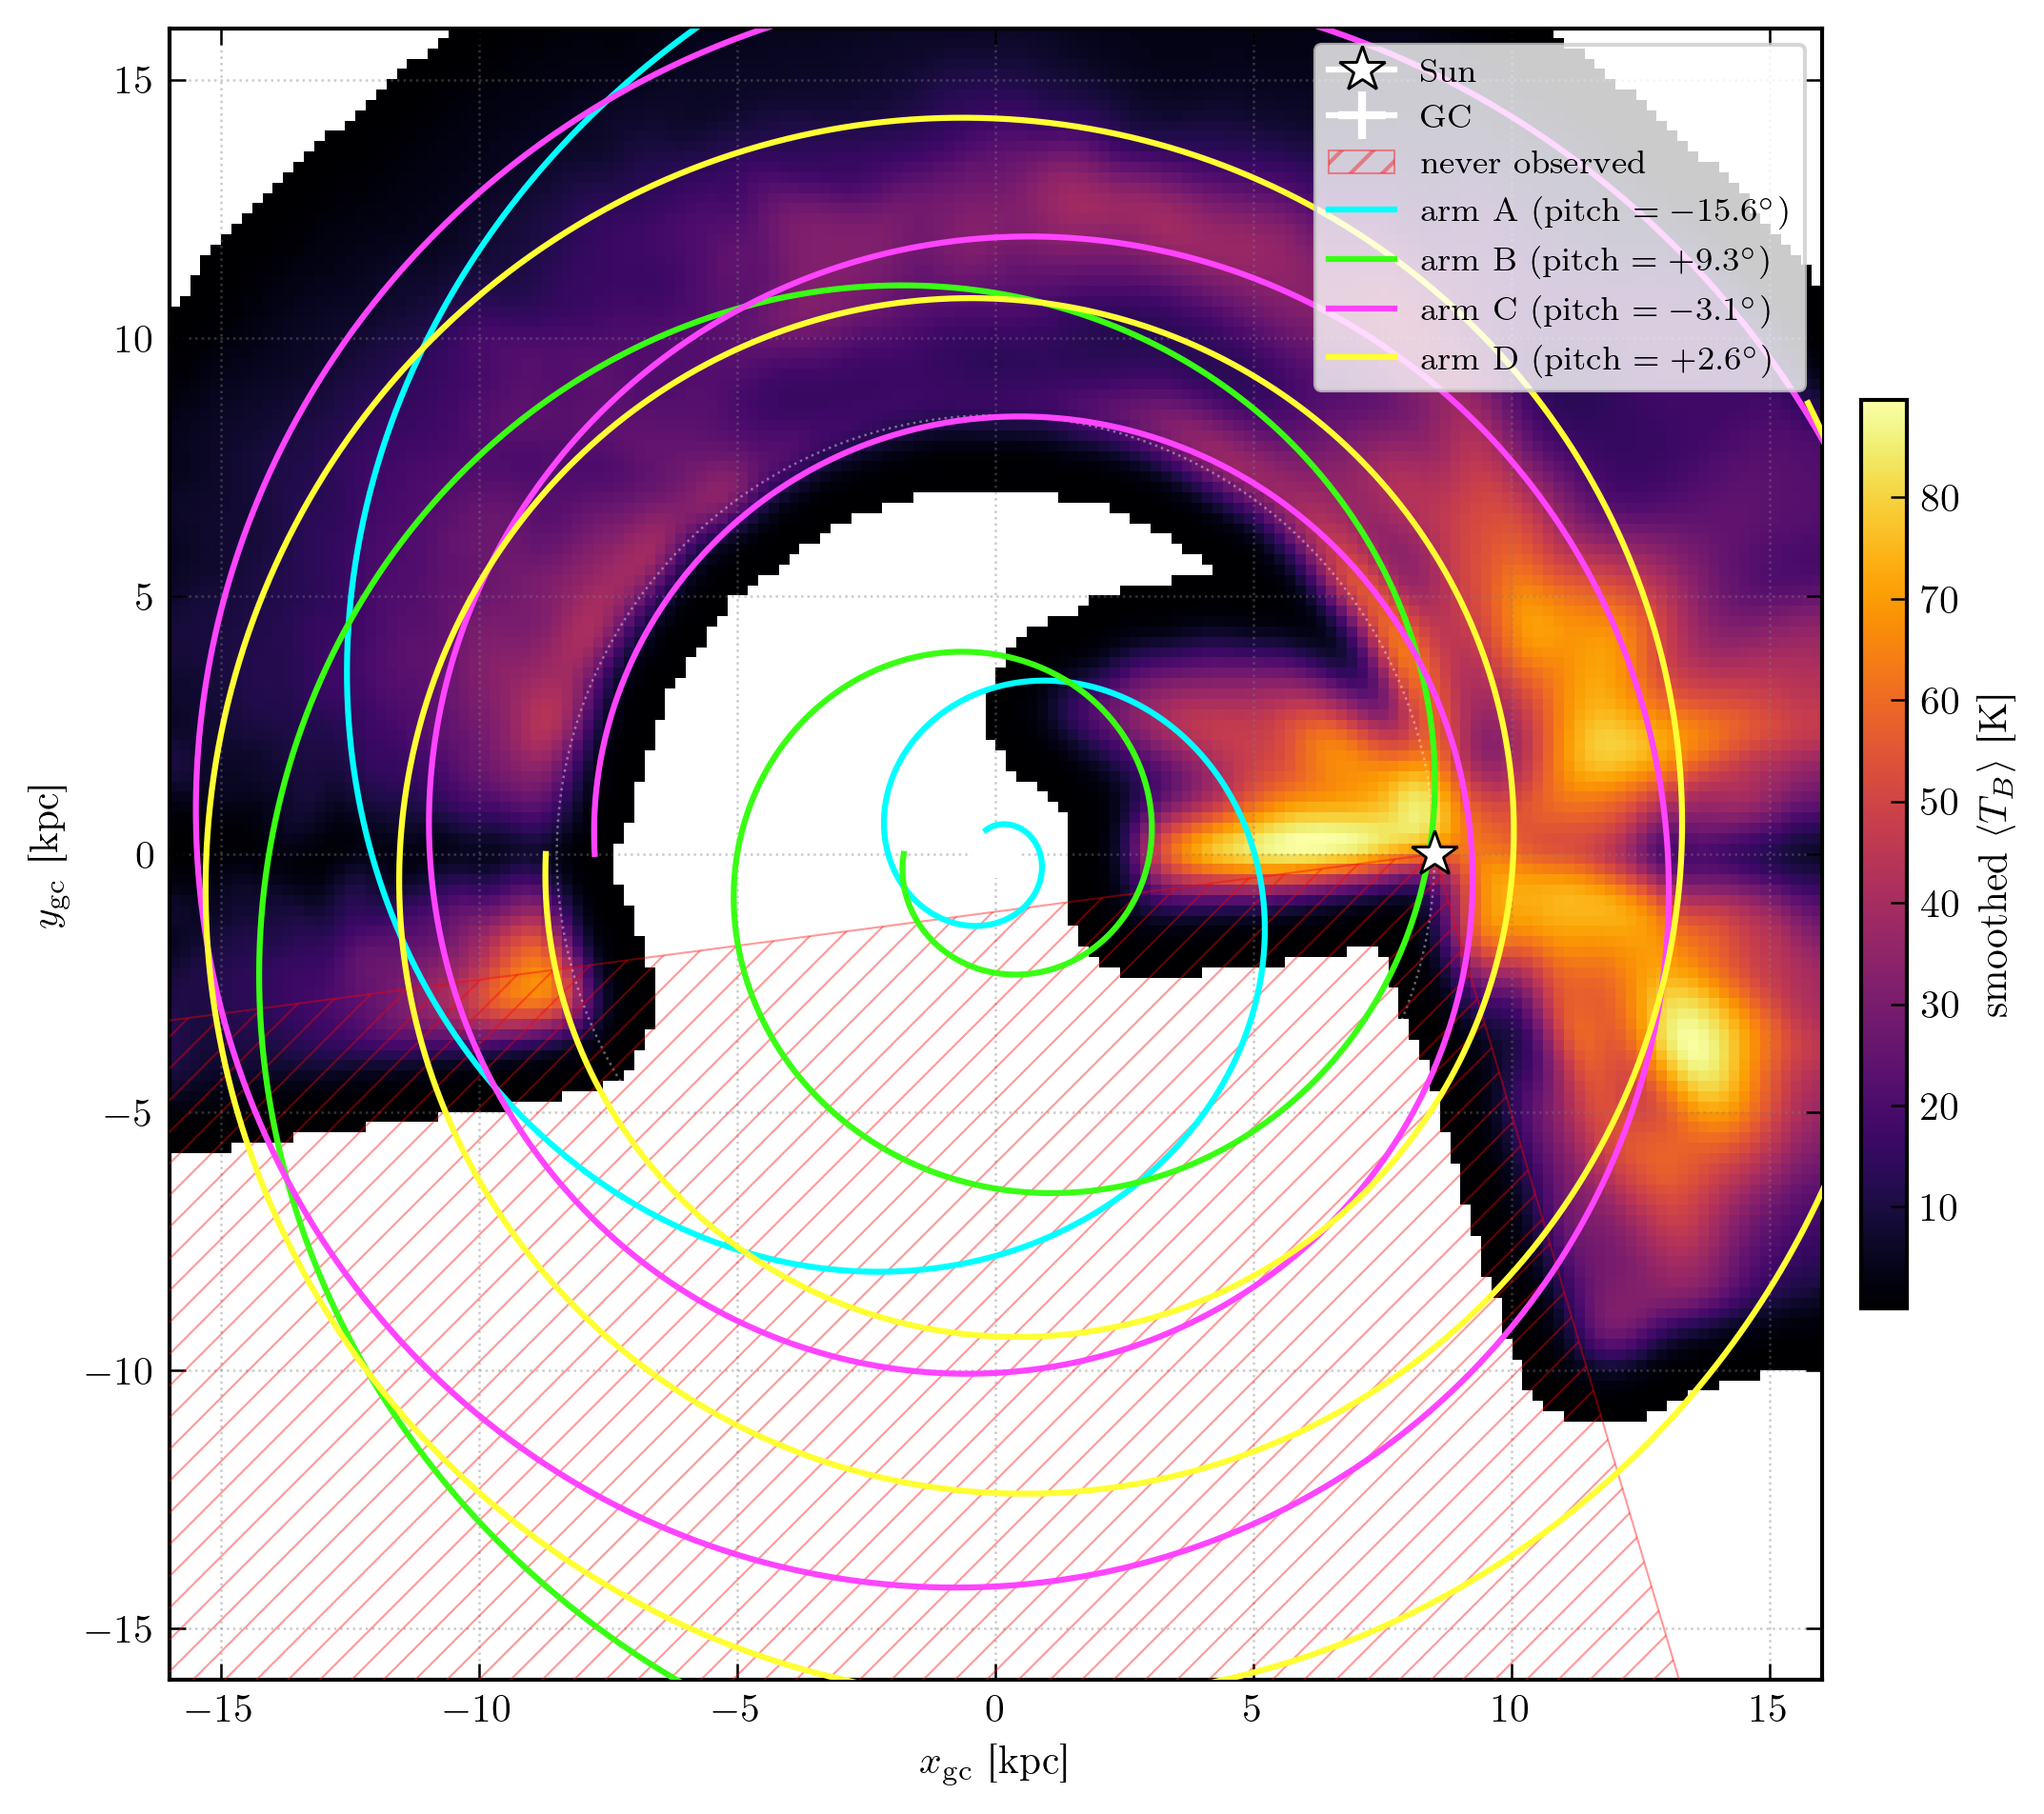

In [8]:
from scipy.ndimage import gaussian_filter

# --- Project lv_image into galactocentric (x, y) on a Cartesian grid -------
XY_MAX_KPC      = 16.0
XY_STEP_KPC     = 0.2
L_PROJ_STEP_DEG = 1.0
GAUSSIAN_SIGMA  = 2.0     # in pixels; ~0.4 kpc at 0.2 kpc/pixel

n_xy   = int(round(2 * XY_MAX_KPC / XY_STEP_KPC))
xy_edges = np.linspace(-XY_MAX_KPC, XY_MAX_KPC, n_xy + 1)

H_T = np.zeros((n_xy, n_xy))   # sum of T_B
H_N = np.zeros((n_xy, n_xy))   # cell count

l_proj_grid = np.arange(L_MIN_SURVEY, L_MAX_SURVEY + 1e-9, L_PROJ_STEP_DEG)
R_inv_grid  = np.linspace(R_INVERT_MIN, R_TRACE_MAX_KPC, 2000)

for l_deg in l_proj_grid:
    l_rad = np.deg2rad(l_deg)
    sin_l, cos_l = np.sin(l_rad), np.cos(l_rad)
    if abs(sin_l) < SIN_L_FLOOR:
        continue
    j = int(np.argmin(np.abs(l_fine - l_deg)))
    spec = lv_image[:, j].astype(float)
    valid = (np.abs(v_lsr) < V_BAND_MAX_KMS) & np.isfinite(spec) & (spec > 0)
    if not valid.any():
        continue
    v_use = v_lsr[valid]
    T_use = spec[valid]
    v_at_R = (V_full(R_inv_grid) / R_inv_grid - V_SUN_KMS / R_SUN_KPC) \
             * R_SUN_KPC * sin_l
    order = np.argsort(v_at_R)
    R_sol = np.interp(v_use, v_at_R[order], R_inv_grid[order],
                      left=np.nan, right=np.nan)
    keep = np.isfinite(R_sol)
    R_sol = R_sol[keep]; T_use = T_use[keep]
    disc = R_sol ** 2 - R_SUN_KPC ** 2 * sin_l ** 2
    keep = disc >= 0
    R_sol = R_sol[keep]; T_use = T_use[keep]; disc = disc[keep]
    sqrt_disc = np.sqrt(disc)
    d_near = R_SUN_KPC * cos_l - sqrt_disc
    d_far  = R_SUN_KPC * cos_l + sqrt_disc
    d = np.where(R_sol >= R_SUN_KPC, d_far, d_near)
    pos = d > 0
    R_sol = R_sol[pos]; d = d[pos]; T_use = T_use[pos]
    x_gc = R_SUN_KPC - d * cos_l
    y_gc = d * sin_l
    ix = np.digitize(x_gc, xy_edges) - 1
    iy = np.digitize(y_gc, xy_edges) - 1
    in_bins = (ix >= 0) & (ix < n_xy) & (iy >= 0) & (iy < n_xy)
    np.add.at(H_T, (iy[in_bins], ix[in_bins]), T_use[in_bins])
    np.add.at(H_N, (iy[in_bins], ix[in_bins]), 1)

# Mean T_B per cell where observed, then smooth.
with np.errstate(invalid="ignore", divide="ignore"):
    H_mean = np.where(H_N > 0, H_T / H_N, 0.0)
H_smooth = gaussian_filter(H_mean, sigma=GAUSSIAN_SIGMA)
H_display = np.where(H_smooth > 0.01, H_smooth, np.nan)

from plotters import plot_kinematic_distance
fig, ax = plot_kinematic_distance(
    l_fine, v_lsr, lv_image, R_Q1, V_Q1,
    fits=arm_fits,
    R_sun_kpc=R_SUN_KPC, V_sun_kms=V_SUN_KMS,
)
plt.show()


**Figure 6.** Top-down kinematic-distance projection of $T_B(\ell, v_{\rm LSR})$ at $b \approx 0$ onto the Galactocentric $(x_{\rm gc}, y_{\rm gc})$ plane. Each $(\ell, v)$ pixel is mapped to a single $(R, \phi)$ via the full-disk rotation curve (measured Q1 $V(R)$ inside $R_\odot$, flat $V_\odot$ outside), then converted to $(x_{\rm gc}, y_{\rm gc})$ using the near branch of the KDA inside the Solar circle and the unique positive solution outside. The Sun sits at $(x, y) = (R_\odot, 0)$; the Galactic centre is at the origin. The two fitted log spirals from Sec.~6 are overlaid in their natural $(R, \phi)$ form. The image is a *visual aid only*: structure is collapsed onto the near-branch surface inside the Solar circle, the radial direction is heavily smeared near the Sun-GC axis where $\sin\ell \to 0$, and only the $b = 0$ strip contributes -- the full Galactic-disk surface density is not represented.


## Discussion and conclusions

### Headline numerical results

- $V(R)$ in the Q1 inner Galaxy is **consistent with a flat rotation curve at $\approx 220$ km/s** across $R \in [3, 7.5]$ kpc; the residual scatter ($\sigma_V \approx 7$-$10$ km/s) matches the expected peculiar-motion contribution.
- $M_{\rm grav}(< R_\odot) \approx 9.6 \times 10^{10}\,M_\odot$ from $V^2(R_\odot)\,R_\odot/G$ -- the canonical dynamical mass inside the Solar circle.
- $M_{\rm gas}(< R_\odot) \in [\,9 \times 10^8,\,2 \times 10^9\,]\,M_\odot$ depending on the KDA branch, implying an HI gas fraction of $\sim 1$-$3\%$ inside the Solar circle (consistent with the literature value of $\sim 1\%$ for HI alone, Kalberla \& Kerp 2009).
- The Galactic rotation curve being flat at $\sim 220$ km/s -- as opposed to the Keplerian $V \propto R^{-1/2}$ expected from the visible stellar mass alone -- is the original observational signature of dark matter inside the Galaxy. Our $\sim 1\%$ HI-only fraction is therefore consistent with the modern picture where most of the dynamical mass at $R \lesssim 10$ kpc is stellar, plus a substantial dark-matter halo at the largest radii probed.

### Spiral structure

The $2$-arm log-spiral fit reproduces the qualitative impression of two arms but is unreliable in its precise pitch angle. HI1.tex Sec.~7.2 warns that finding spiral arms inside the Solar circle "has thwarted efforts by astronomers over the past several decades", and the present analysis confirms this assessment: the fit instabilities (arm crossings in $(\ell, v)$ space, peak coincidence when two arms overlap in $v_{\rm LSR}$ within a beam-broadened linewidth, and the kinematic-distance ambiguity at the conversion step) are catalogued explicitly in Sec.~6.1 (the "Where the 2-arm fit fails" subsection). We present the fit as illustrative, not measured. A real arm-tracing analysis would use parallax masers (e.g.\ Reid et al.\ 2014) or HI self-absorption to break the KDA and disentangle overlapping arms -- neither feasible with single-dish $b = 0$ data alone.

### Galactic centre and BH mass

The anomalous-velocity gas visible at $|\ell| \lesssim 5^\circ$ in Figure 1 extends well beyond the tangent-point envelope, with velocities of order $\pm 200$ km/s at $\ell \approx 0$ where pure rotation would predict $V_{\rm LSR} \approx 0$. This kinematic chaos reflects the central few hundred parsecs of the Galaxy, where the gravitational potential is dominated by the nuclear stellar cluster and the central SMBH (Sgr A*, $M_\bullet \approx 4 \times 10^6\,M_\odot$ from VLT/Keck stellar orbits at $\sim 0.01$ pc). With our $3.4^\circ$ FWHM beam subtending $\approx 500$ pc at the Galactic centre -- five orders of magnitude larger than the BH sphere of influence ($\sim 2$ pc) -- we cannot resolve any structure on the relevant scale. Plugging the largest observed anomalous velocity ($\sim 200$ km/s) and the smallest distance we can claim from the data ($\sim 250$ pc, half the beam at the GC distance) into the simple-minded $M = v^2 r/G$ gives a loose lower bound of order $10^9\,M_\odot$ -- four orders of magnitude *above* the true $M_\bullet$ because we are seeing the gravitational potential of the entire enclosed stellar mass on those scales, not the BH alone. This bound is reported only to make the point that the lab cannot do better; HI1.tex Sec.~7.2 explicitly states that "to get an accurate estimate, you need to look at motions of matter lying really close to the black hole, which you can't do because you don't have the angular resolution." We agree.

### Systematic limitations

1. **Optically thin assumption** breaks at $\tau \sim 1$ in inner-plane sightlines; the recovered $W$ saturates near the spin temperature in those channels. The reported $M_{\rm gas}(R)$ is a *lower bound* in the inner disk. A spin-temperature correction would add $\sim 30\%$ to the inner-Galaxy gas mass (Kalberla 2003).
2. **Kinematic-distance ambiguity** inside the Solar circle: the near/far branches bracket the truth but cannot be resolved per-pixel. The systematic spread between near and far profiles is the irreducible KDA uncertainty band.
3. **Outer-Galaxy rotation curve assumed flat** at $V(R) = 220$ km/s for $R > R_\odot$. Independent measurements (Brand \& Blitz 1993; Reid et al.\ 2014) confirm flatness to within $\sim 10\%$, but our derived outer-Galaxy gas mass is sensitive to this.
4. **Pure circular rotation**: real Galactic kinematics include $\sim 10$ km/s peculiar motions and a non-axisymmetric bar potential at $R \lesssim 4$ kpc. The rotation curve we extract is an azimuthally averaged $V(R)$ along the Q1 tangent locus.
5. **Survey coverage** is limited to longitudes accessible from Leuschner: $\ell \in [-60^\circ, +300^\circ]$ after wrap. Most of Q4 ($\ell \in [-180^\circ, -90^\circ]$, equivalently $\ell \in [180^\circ, 270^\circ]$ in the wrap) is not accessible, so the rotation curve is constrained on Q1 only and the spiral fit is asymmetric.

### Comparison to upstream notebooks

This notebook reuses the calibrated $\ell$-$v$ strip and the gridded $W$ map from `main_scan_data_products.ipynb` directly. The science transformations (tangent-point extraction, mass derivations, spiral fit, kinematic-distance projection) are all self-contained here and do not modify upstream products. The persisted artifact `artifacts/galactic_plane_products.pkl` carries the fitted rotation curve, the enclosed mass profiles, the spiral parameters, and the top-down projection for use by the warp project notebook or future analyses.

### Conclusion

The five science deliverables of HI1.tex Sec.~7 are recovered: a position--velocity image, an inner-Galaxy rotation curve consistent with $V \approx 220$ km/s and the Brand & Blitz literature, an enclosed gravitational mass of $\sim 10^{11}\,M_\odot$ at $R_\odot$, an HI gas mass of order $10^9\,M_\odot$ with an explicit KDA-driven uncertainty band, and an illustrative -- but honest about its limits -- $2$-arm log-spiral overlay. The Galactic centre is not resolvable with the present beam; we report this as a caveat rather than a quantitative BH-mass measurement, in line with HI1.tex's own qualification. The optically-thin and pure-circular-rotation assumptions are the dominant systematic uncertainties, both of which would require additional data (HI self-absorption, parallax masers) to address. Within those caveats the survey delivers a coherent picture of the Galactic rotation and gas distribution at $3.4^\circ$ angular resolution.


## Report figures (saved to `report/figures/`)


## Report figures (saved to `report/figures/`)


## Report figures (saved to `report/figures/`)


## Report figures (saved to `report/figures/`)


## Report figures (saved to `report/figures/`)


/home/ikaros/projects/ay-121/labs/04/plotters.py:1595: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  fig_rotation_curve.pdf


  fig_mass_grav.pdf


  fig_mass_gas.pdf


  fig_spiral_lv.pdf


  fig_kinematic_distance.pdf


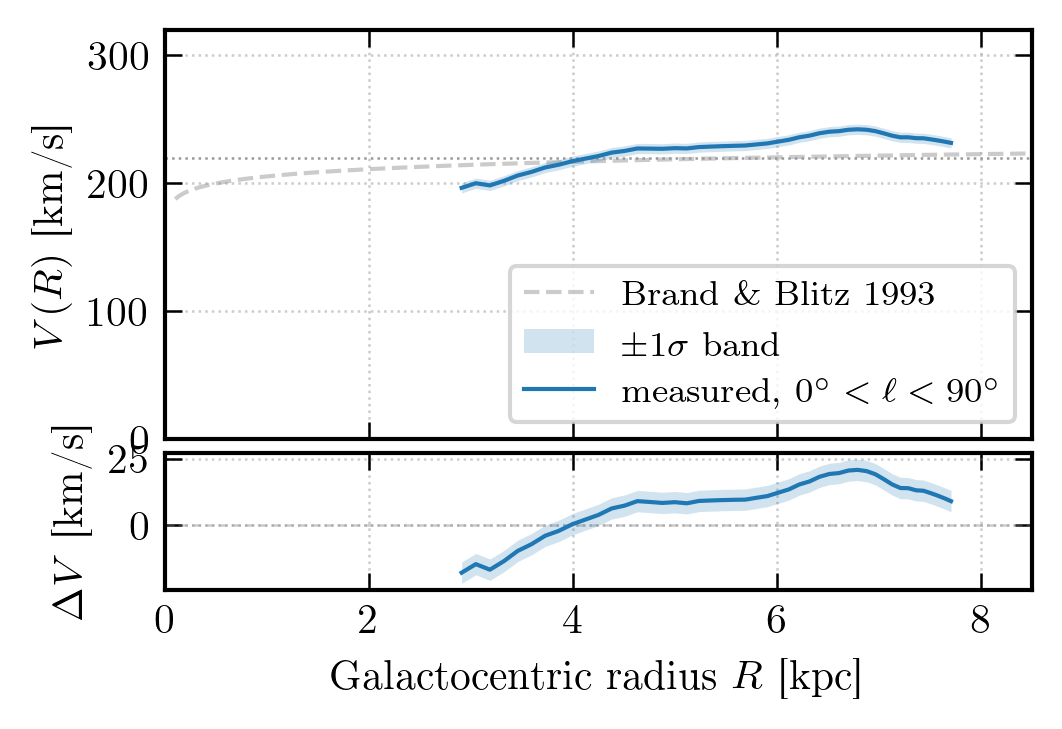

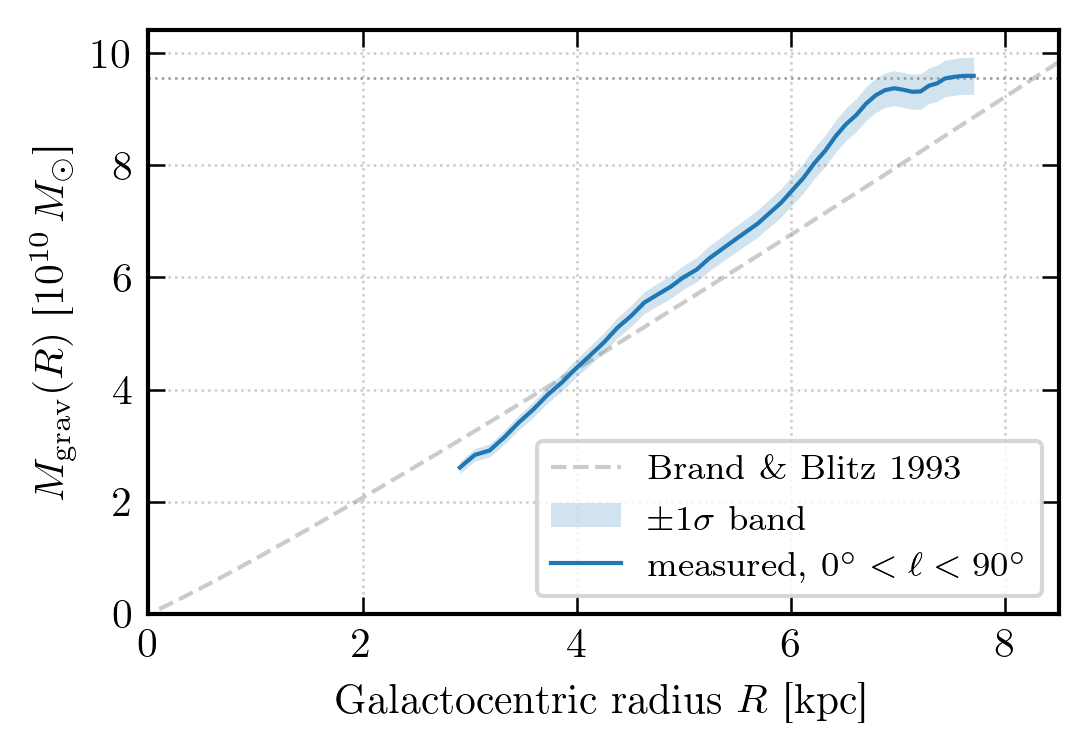

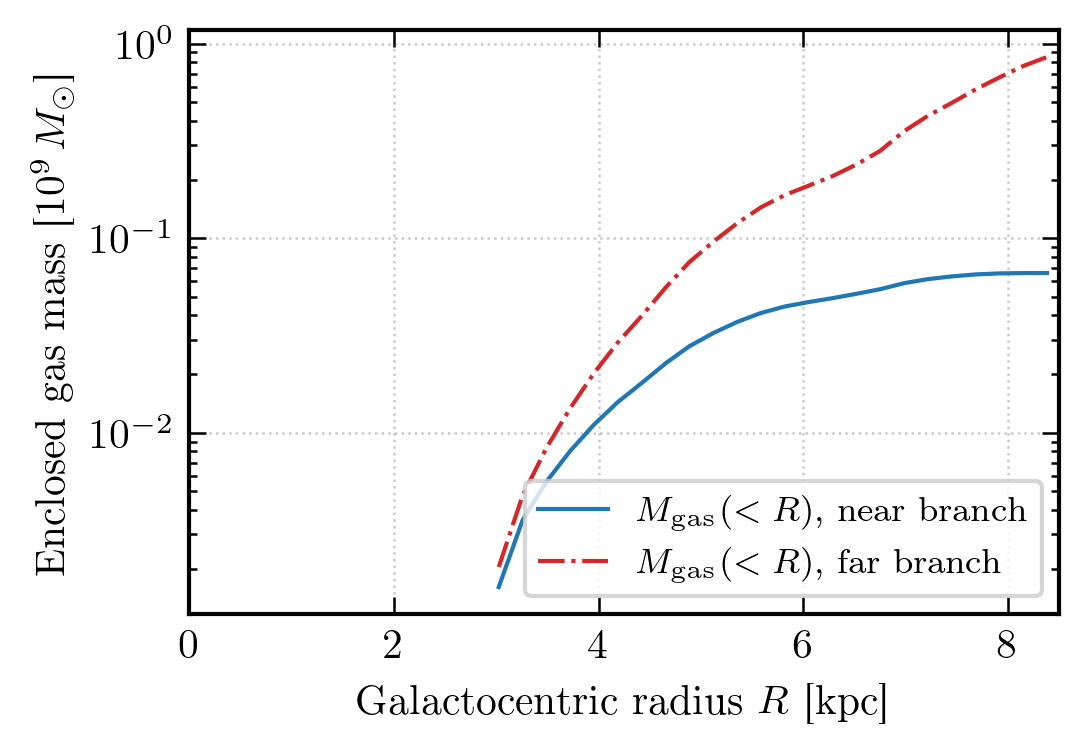

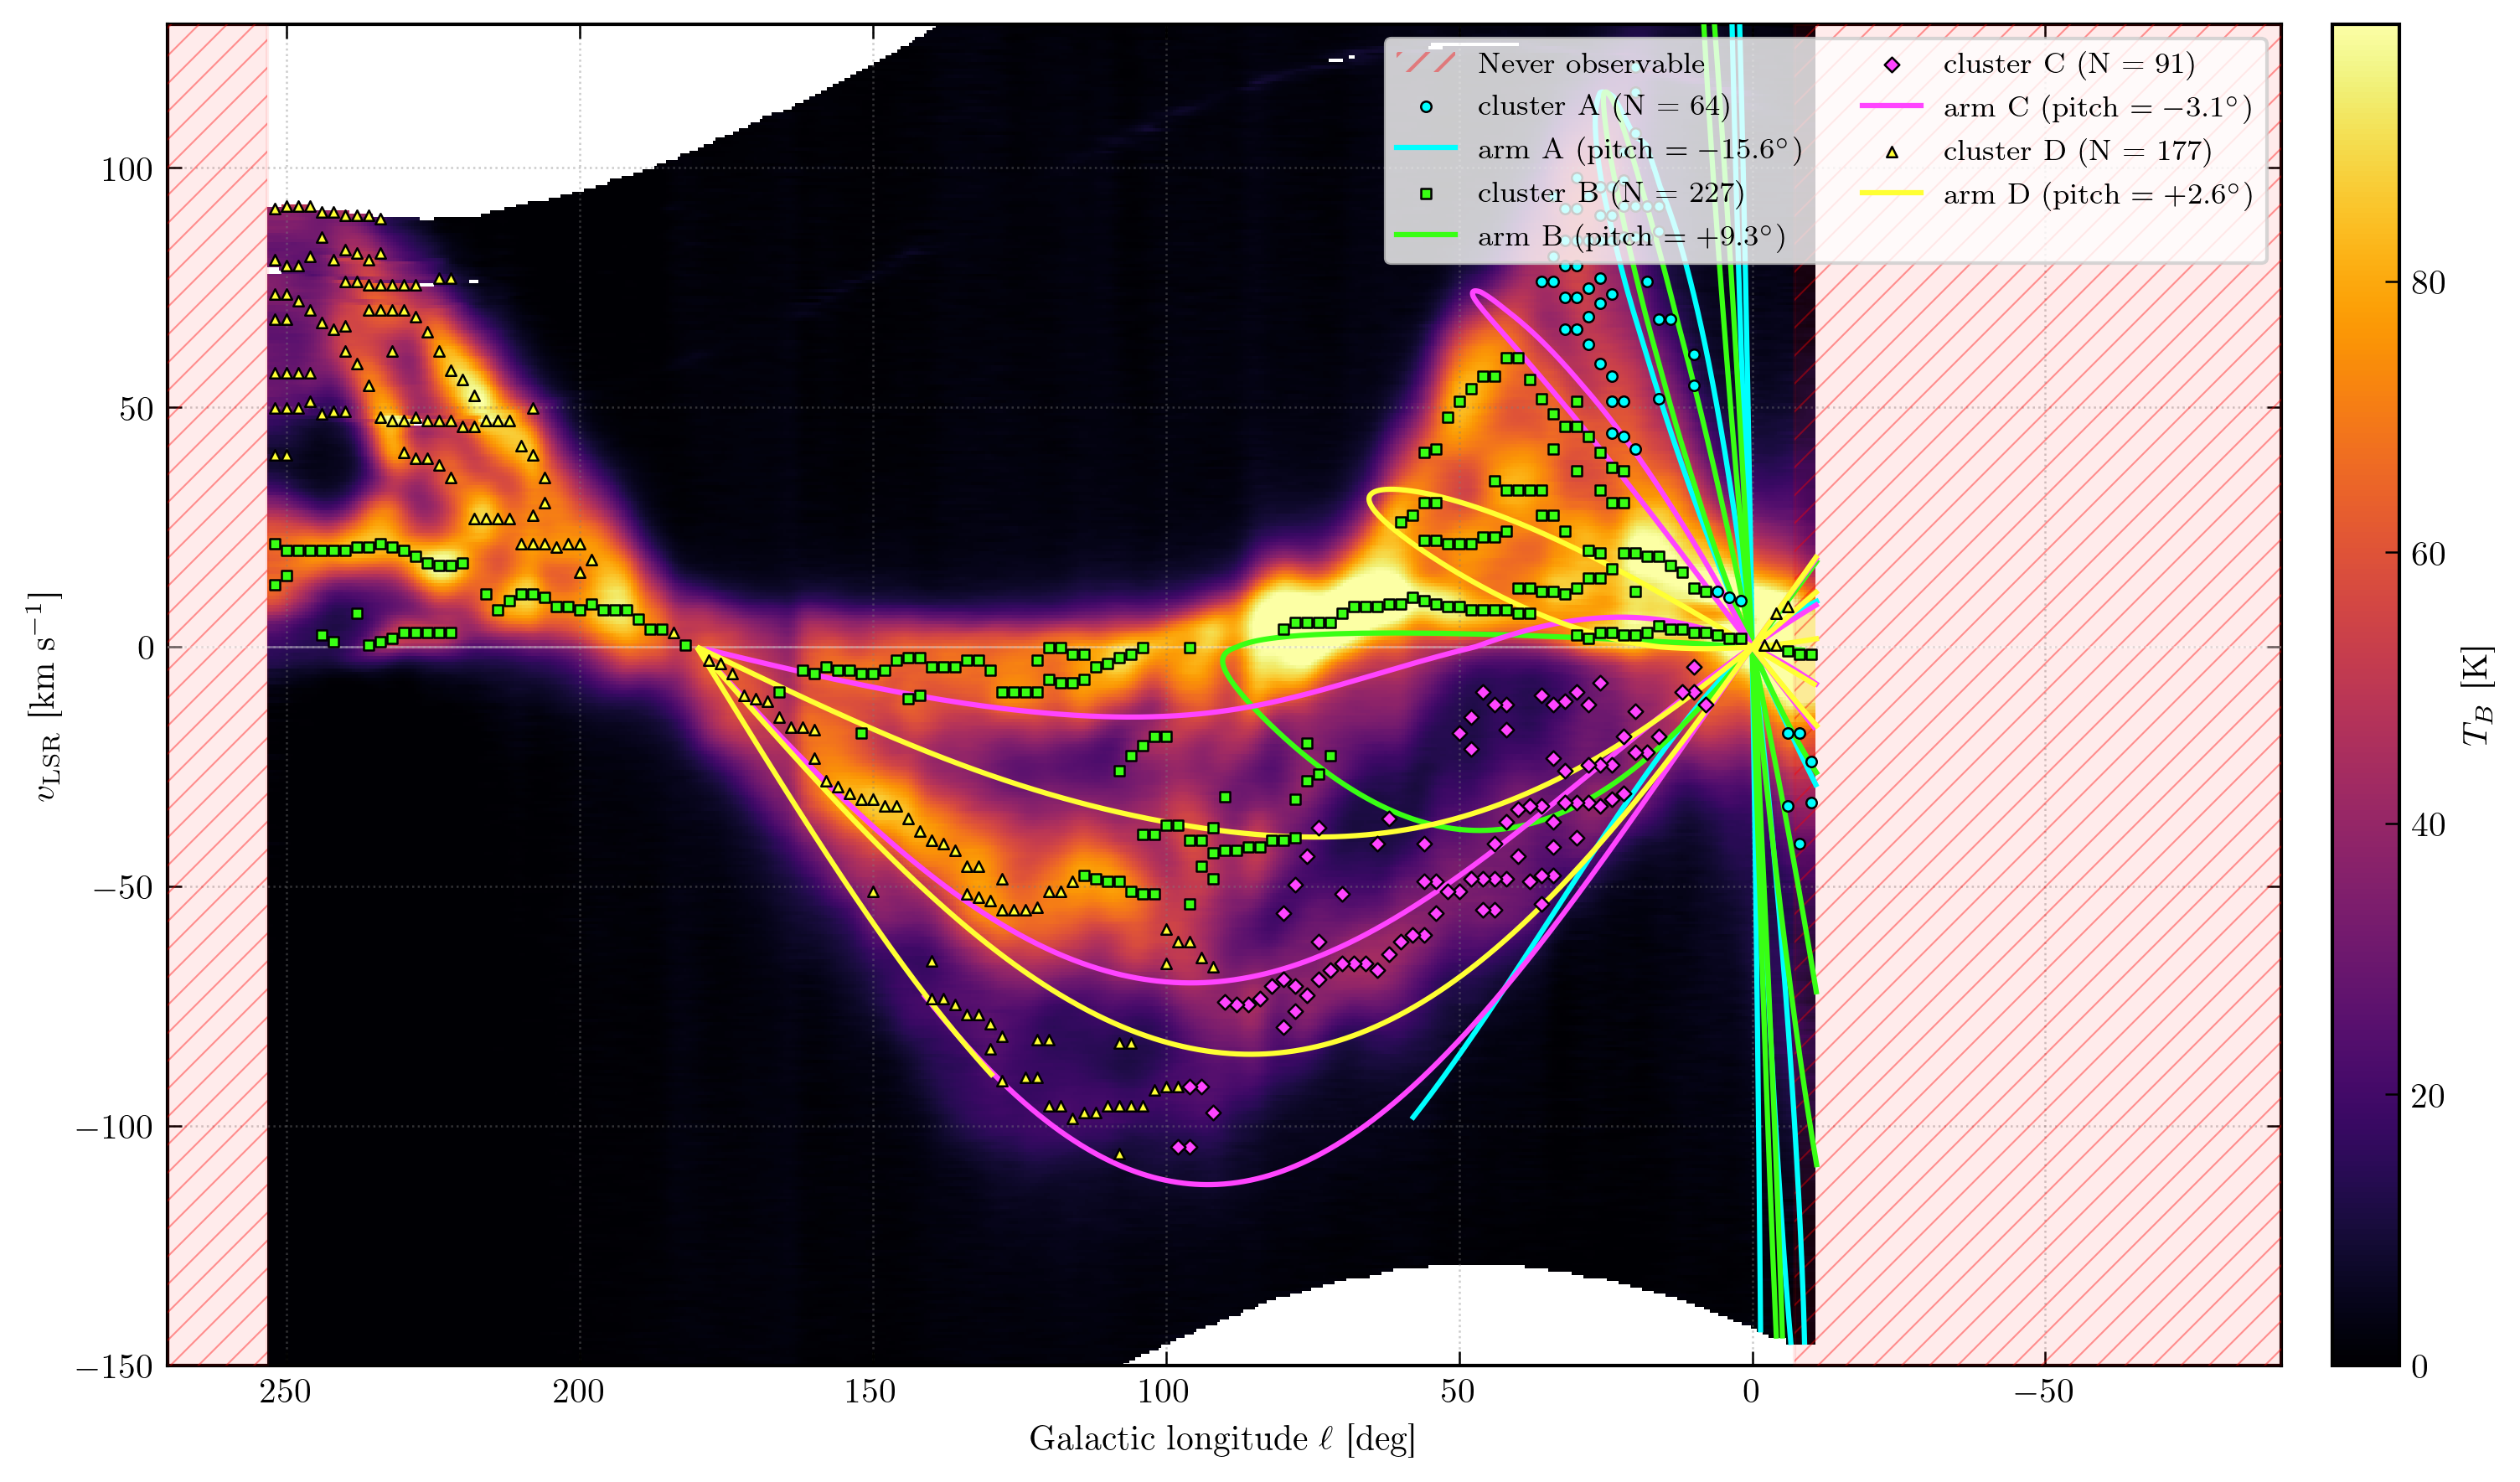

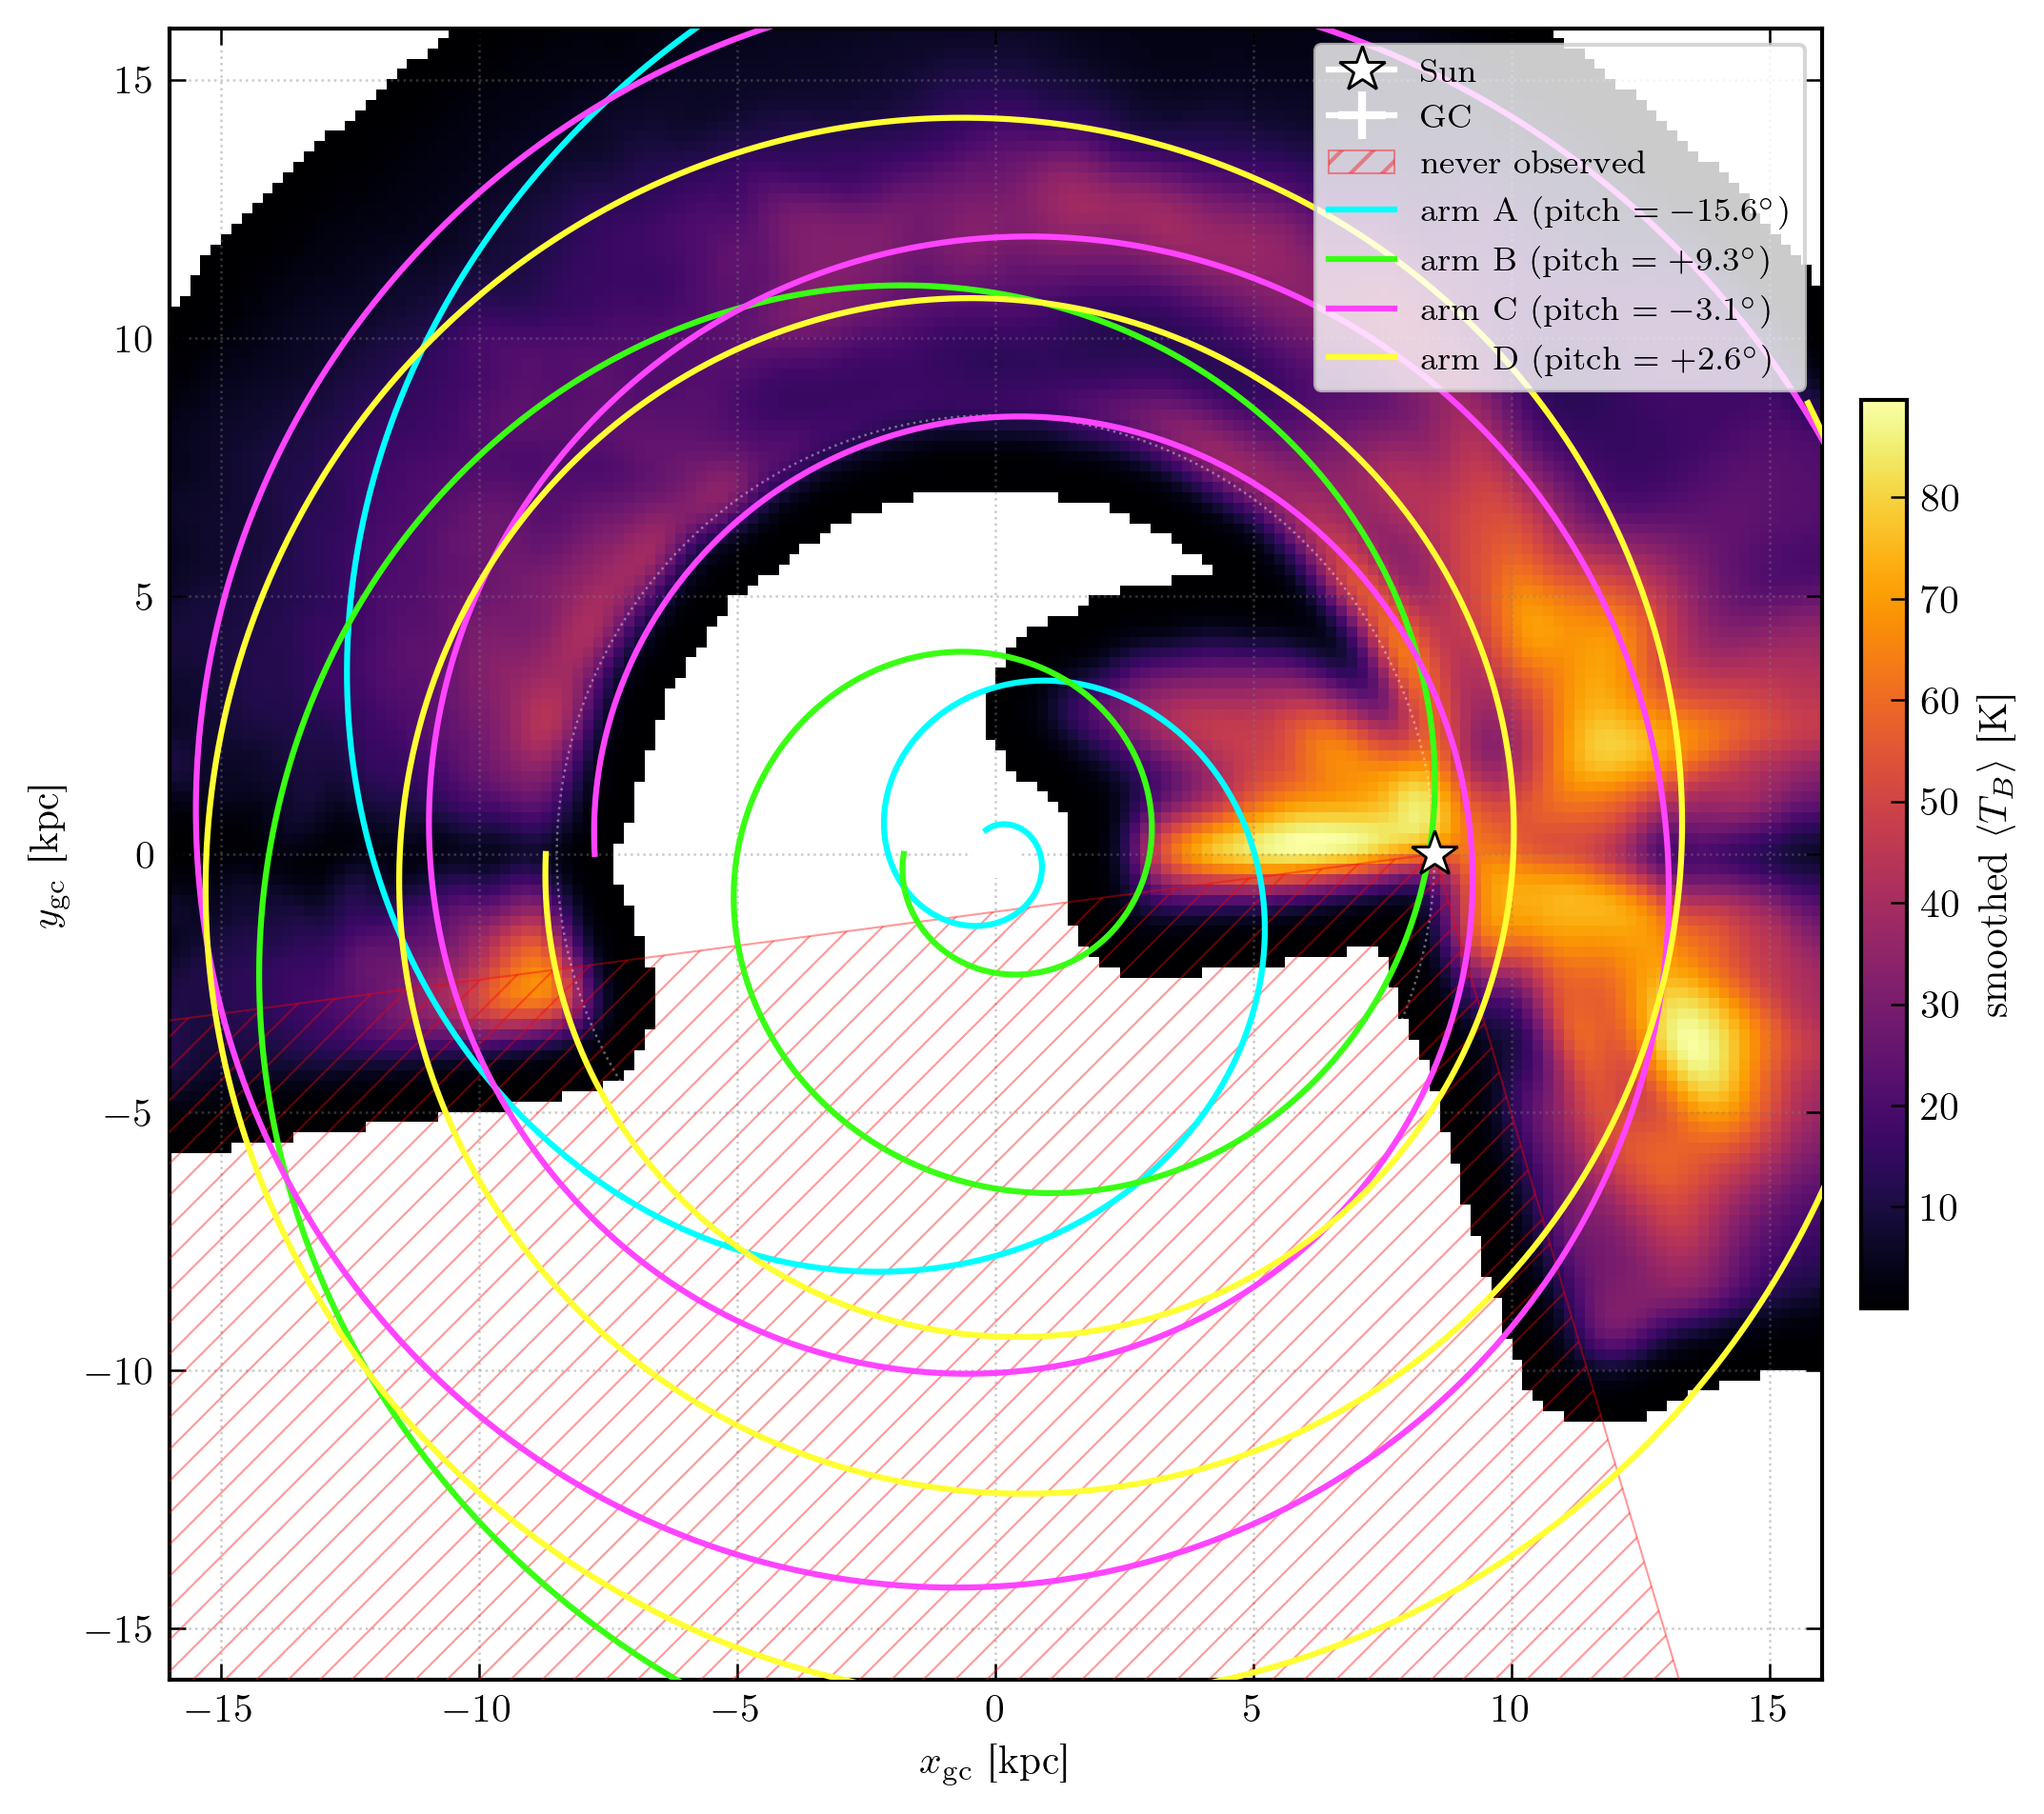

In [9]:
# === Report figures (auto-saved to report/figures/) ===
from plotters import (savefig, plot_rotation_curve_burton,
                      plot_mass_grav, plot_mass_gas,
                      plot_spiral_lv_overlay,
                      plot_kinematic_distance)

fig, _ = plot_rotation_curve_burton(
    R_Q1, V_Q1, R_sun_kpc=R_SUN_KPC, V_sun_kms=V_SUN_KMS,
    L_TP_MIN_DEG=L_TP_MIN_DEG, L_TP_MAX_DEG=L_TP_MAX_DEG,
    FRAC_OF_PEAK=FRAC_OF_PEAK,
)
savefig(fig, 'fig_rotation_curve.pdf')

fig, _ = plot_mass_grav(R_Q1, V_Q1,
                       R_sun_kpc=R_SUN_KPC, V_sun_kms=V_SUN_KMS)
savefig(fig, 'fig_mass_grav.pdf')

fig, _ = plot_mass_gas(R_bin_centers, M_gas_near_bin, M_gas_far_bin,
                       R_sun_kpc=R_SUN_KPC)
savefig(fig, 'fig_mass_gas.pdf')

# K=4 spiral overlay (recomputes K-means + fit internally).
fig, _, fits_report = plot_spiral_lv_overlay(
    l_fine, v_lsr, lv_image, R_Q1, V_Q1,
    R_sun_kpc=R_SUN_KPC, V_sun_kms=V_SUN_KMS, K=4,
)
savefig(fig, 'fig_spiral_lv.pdf')

# Top-down kinematic-distance projection with same arm overlays.
fig, _ = plot_kinematic_distance(
    l_fine, v_lsr, lv_image, R_Q1, V_Q1,
    fits=fits_report,
    R_sun_kpc=R_SUN_KPC, V_sun_kms=V_SUN_KMS,
)
savefig(fig, 'fig_kinematic_distance.pdf')
